In [1]:
import subprocess
import pydot
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from collections import defaultdict
from scipy.stats import poisson, norm, chisquare, chi2, binom
import time
import pandas as pd
import numpy as np
import math

# Анализ графов

Код для замера времени исполнения генерации

In [29]:
def measure_execution_time(program, num_vertices, density, num_trials):
    total_time = 0
    for _ in range(num_trials):
        start_time = time.time()
        subprocess.run([program, str(num_vertices), str(density)], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
        end_time = time.time()
        execution_time = end_time - start_time
        total_time += execution_time
        # print(execution_time)
    average_time = total_time / num_trials
    return average_time

# g++ -std=c++17 -O3 -march=native -I./ -I./randomizer -I./common -I/prufer_graph -I/randomizer -o a main_prufer.cpp
# перед тестированием удалить из программы запись в файл
# subprocess.run(["g++", "-std=c++17", "-O3", "-march=native", "-o", "a", "prufer_prod.cpp"], check=True)
program_name = "a.exe"
num_vertices = 10000
density = 0.1  # плотность 0.1
num_trials = 10
average_execution_time = measure_execution_time(program_name, num_vertices, density, num_trials)
print(f"Average execution time over {num_trials} trials: {average_execution_time:.6f} seconds")

Average execution time over 10 trials: 0.931511 seconds


**Демонстрация генератора**

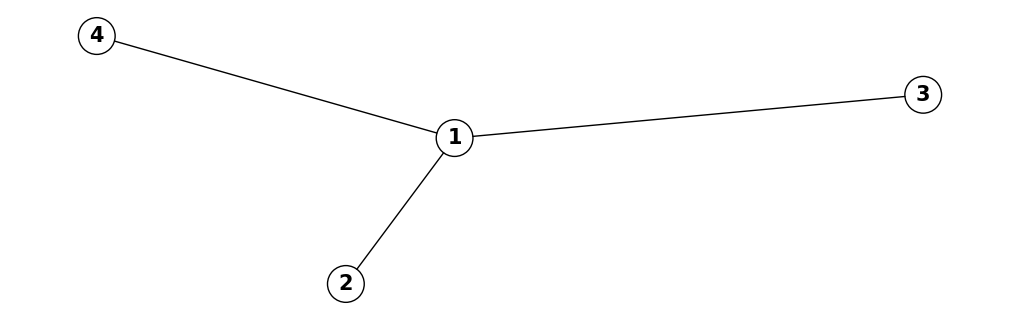

In [56]:
# Компиляция prufer.cpp с помощью g++
#subprocess.run(["g++", "-std=c++17", "-O3", "-march=native", "-o", "a", "prufer.cpp"], check=True)
# Запуск a.exe и ожидание завершения
subprocess.run(["a.exe", "4", "0"], check=True)

# Загружаем граф из файла в формате dot с помощью networkx и pydot
G = nx.nx_pydot.read_dot('graph.dot')

# Рисуем дерево
plt.figure(figsize=(10, 3))
nx.draw(G, 
        with_labels=True, 
        node_size=700,
        node_color="none",
        edgecolors="black",
        font_size=15, 
        font_weight='bold', 
        edge_color='black', 
        font_color='black') 
plt.show()

**Построение гистограммы**

In [1]:
# Функция для чтения рёбер из файла DOT
def read_dot_edges(dot_file):
    edges = []
    with open(dot_file, 'r') as f:
        for line in f:
            if '--' in line:
                parts = line.strip().strip(';').split(' -- ')
                if len(parts) == 2:
                    edges.append(tuple(map(int, parts)))
    return edges

# Функция сбора статистики
def get_sample_4deg(n, trials, density):
    all_degrees = []
    for i in range(trials):
        # Запускаем генерацию графа
        subprocess.run(["a.exe", str(n), str(density)], check=True)
        # Читаем рёбра из файла
        edges = read_dot_edges('graph.dot')
        # Подсчитываем степени вершин
        degree_count = defaultdict(int)  # Сброс перед каждым испытанием
        for u, v in edges:
            degree_count[u] += 1
            degree_count[v] += 1
        # Добавляем степени всех вершин в общий список
        all_degrees.extend(degree_count.values())
    return all_degrees

Использование генератора

In [6]:
# Количество вершин
n = 100
# Плотность
density = 0.1
# Количество испытаний
trials = 10000
# Список для хранения степеней всех вершин во всех испытаниях
all_degrees = get_sample_4deg(n, trials, density)

# Определяем диапазон значений степеней вершин
min_degree = min(all_degrees)
max_degree = max(all_degrees)

In [ ]:
# Число бинов
num_bins = (n - 1)//4  # Бины от 1 до N-1, то есть, для 4 вершин, бины от 1 до 3
# Определяем границы бинов
bin_edges = np.arange(0.5, n + 0.5, n/(num_bins + 1))

# Строим гистограмму степеней вершин с использованием указанных границ бинов
plt.hist(all_degrees, bins=bin_edges, edgecolor='black', alpha=0.7)
plt.title('Гистограмма степеней вершин')
plt.xlabel('Степень вершины')
plt.ylabel('Частота')

# Показать гистограмму
plt.show()

'''
# Используем логарифмическую оценку для количества бинов
num_bins = n#math.ceil(math.log2(len(all_degrees)) + 1)

# Строим гистограмму степеней вершин
plt.hist(all_degrees, bins=num_bins, edgecolor='black', alpha=0.7)
plt.title('Гистограмма степеней вершин')
plt.xlabel('Степень вершины')
plt.ylabel('Частота')
plt.show()
'''
hist_values, bin_edges = np.histogram(all_degrees, bins=bin_edges)

# Выводим частоты для каждого бина
print("Частоты по бинам:", hist_values)
print("Границы бинов:", bin_edges)

Анализ гистограммы с ипользованием построения в c++

In [174]:
import numpy as np

def read_vector_from_file(filename):
    with open(filename, 'rb') as file:
        # Читаем размер вектора
        size = np.fromfile(file, dtype=np.uint64, count=1)[0]

        # Читаем данные вектора
        vec = np.fromfile(file, dtype=np.int32, count=size)

    return vec

# Чтение вектора из файла
deg = read_vector_from_file('histogram.bin')#[1:] # степени 0 быть не может, т.к. граф связен по построению
#deg = deg[60:]
deg = deg[1:-2]
# Выводим содержимое вектора
#print(deg)

degrees = np.arange(1, len(deg) + 1)

plt.figure(figsize=(12, 8), dpi=1000)  # 8x6 дюймов и 100 DPI

# Определяем границы по ненулевым значениям
nonzero_indices = np.nonzero(deg)[0]
xmin, xmax = nonzero_indices[0]-0.5, nonzero_indices[-1]+0.5
# Построение гистограммы
plt.bar(degrees, deg/sum(deg), width=1.0, align='center', color='#F5C99B', edgecolor='black', alpha = 1)
plt.xlim([xmin, xmax])
plt.grid(axis='y')
# Настройка подписей и заголовка
plt.xlabel('Степень')
plt.ylabel('Частота')
plt.title('Гистограмма степеней графа. $p = 1000, d = 0.1$')
# Отображение графика
plt.show()

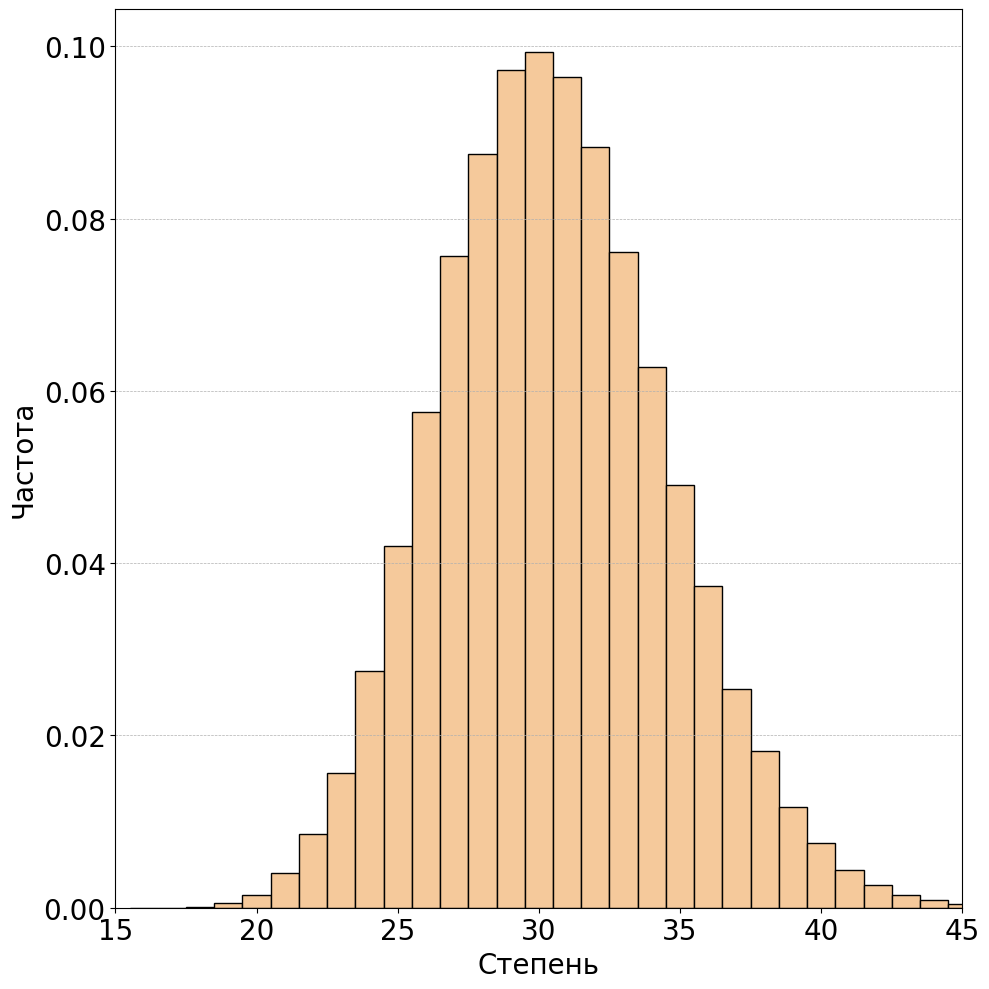

In [ ]:
p = 100
trials = 10e6
def read_vector_from_file(filename):
    with open(filename, 'rb') as file:
        size = np.fromfile(file, dtype=np.uint64, count=1)[0]
        vec = np.fromfile(file, dtype=np.int32, count=size)
    return vec

deg = read_vector_from_file('histogram2.bin')
deg = deg[1:-2]  # Убираем 0-й элемент и последние два

# Убираем нулевые значения
nonzero_mask = deg > 0
degrees = np.arange(1, len(deg) + 1)[nonzero_mask]
deg = deg[nonzero_mask]

# Нормируем частоты
freq = deg / sum(deg)

# Устанавливаем общий размер шрифта
fontsize_value = 16
axis_label_fontsize = 20  # Для подписей на осях
tick_label_fontsize = 20  # Для делений на осях

# 📌 Обычная гистограмма (с подписями для каждого бина)
plt.figure(figsize=(10, 10), dpi = 100)

plt.bar(degrees, freq, width=1.0, align='center', color='#F5C99B', edgecolor='black', alpha=1)
plt.xlim([min(degrees) - 1, max([degrees[i] for i in range(len(degrees)) if freq[i] > 0.0005]) + 1])
plt.xlabel('Степень', fontsize=axis_label_fontsize)
plt.ylabel('Частота', fontsize=axis_label_fontsize)
#plt.title(f'Гистограмма степеней дерева. $p = ${p}, $trials = 10^6$', fontsize=fontsize_value + 2)

# Подписываем значения каждого бина
# for i, v in enumerate(freq):
#     if v < 0.0005:
#         break
#     plt.text(degrees[i], v, f'{v:.4f}', ha='center', va='bottom', fontsize=fontsize_value - 2)

# Увеличиваем шрифт делений на осях
plt.tick_params(axis='both', labelsize=tick_label_fontsize)

plt.grid(axis='y', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

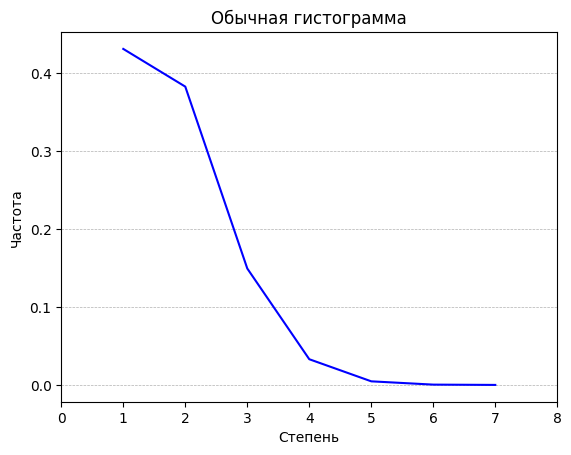

In [139]:
plt.plot(degrees, freq, color='blue', alpha=1)
plt.xlim([min(degrees) - 1, max(degrees) + 1])
plt.xlabel('Степень')
plt.ylabel('Частота')
plt.title('Обычная гистограмма')
plt.grid(axis='y', linestyle='--', linewidth=0.5)

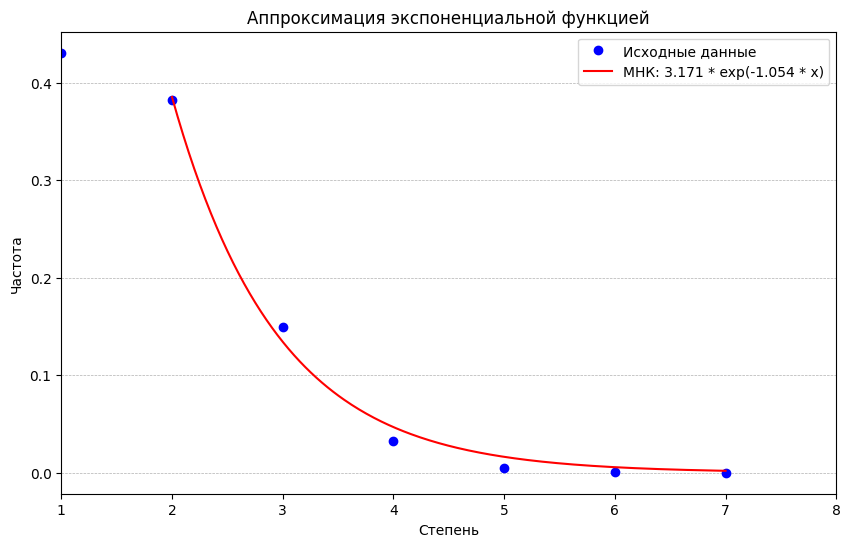

In [140]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Функция для аппроксимации
def exp_func(x, a, b):
    return a * np.exp(-b * x)

# Исключаем первую степень
xdata = degrees[1:]
ydata = freq[1:]

# Начальные приближения для a и b
initial_guess = [max(ydata), 0.1]

# Аппроксимация методом наименьших квадратов
params, _ = curve_fit(exp_func, xdata, ydata, p0=initial_guess)

# Полученные параметры
a_opt, b_opt = params

# Генерация значений для гладкой кривой
x_fit = np.linspace(min(xdata), max(xdata), 300)
y_fit = exp_func(x_fit, a_opt, b_opt)

# Построение графика
plt.figure(figsize=(10, 6))
plt.plot(degrees, freq, 'bo', label="Исходные данные")  # Данные
plt.plot(x_fit, y_fit, 'r-', label=f"МНК: {a_opt:.3f} * exp(-{b_opt:.3f} * x)")  # Аппроксимация
plt.xlim([min(xdata) - 1, max(xdata) + 1])
plt.xlabel('Степень')
plt.ylabel('Частота')
plt.title('Аппроксимация экспоненциальной функцией')
plt.legend()
plt.grid(axis='y', linestyle='--', linewidth=0.5)

plt.show()

**Проверка гипотезы о нормальности**

In [3]:
def norm_xi2(degrees, deg, labtext = 'Степень', isBar = False):
    # Индексы степеней (x-координаты)
    degrees = np.arange(len(deg))

    # Находим среднее и стандартное отклонение по данным (с учетом частот)
    mean = np.average(degrees, weights=deg)
    std_dev = np.sqrt(np.average((degrees - mean) ** 2, weights=deg))

    # Вычисление ожидаемых частот
    total_count = np.sum(deg)  # Общее количество данных
    expected_freq = total_count * norm.pdf(degrees, mean, std_dev)  # Переводим PDF в частоты

    # Коррекция малых значений, чтобы избежать деления на 0
    expected_freq[expected_freq < 1e-6] = 1e-6

    # Вычисление статистики хи-квадрат
    chi_statistic = np.sum((deg - expected_freq) ** 2 / expected_freq)

    # Число степеней свободы (уменьшаем, если объединяем редкие классы)
    dfree = len([i for i in deg if i > 0]) - 3  # len(degrees) - 3  # Отнимаем 1 за число параметров (μ, σ) и 1 за нормализацию

    # Критическое значение хи-квадрат
    alpha = 0.01
    chi_critical = chi2.ppf(1 - alpha, dfree)

    # Форматируем строку для легенды с статистикой и критическим значением
    chi_label = r"$\chi^2 = $" + f"{chi_statistic:.2f}, \n" + r"$\chi^2_{max} = $" + f"{chi_critical:.2f}"

    #chi_label = "$\xi^2$: {chi_statistic:.2f}, Критическое значение: {chi_critical:.2f}"

    # Вывод результатов
    print(f"Среднее: {mean:.2f}, СКО: {std_dev:.2f}")
    print(f"Статистика критерия хи-квадрат: {chi_statistic:.2f}")
    print(f"Критическое значение хи-квадрат при alpha={alpha}: {chi_critical:.2f}")

    # Проверка гипотезы
    if chi_statistic < chi_critical:
        print("Гипотеза о нормальности НЕ отвергается.")
    else:
        print("Гипотеза о нормальности отвергается.")

    # Построение графика
    plt.figure(figsize=(11, 6), dpi=500)  # 8x6 дюймов и 100 DPI

    # Визуализация

    if isBar == False:
        plt.bar(degrees, deg/sum(deg), width=1.0, align='center', color='#F5C99B', edgecolor='black', label="Наблюдаемые частоты", alpha = 1)
        plt.plot(degrees, expected_freq/sum(expected_freq), color='blue', linestyle='dashed', linewidth=2, label="Ожидаемые частоты", alpha=1)
    else:
        plt.bar(degrees, deg/sum(deg), width=1.0, align='center', color='#F5C99B', edgecolor='black', label="Наблюдаемые частоты", alpha = 0.5)
        plt.bar(degrees, expected_freq/sum(expected_freq), width=0.6, align='center', color='red', edgecolor='black', label="Ожидаемые частоты", alpha=0.3)     

    # Добавляем легенду с дополнительной информацией
    plt.legend(title=chi_label)

    # Настройки отображения
    plt.xlim([degrees[deg > 0][0] - 0.5, degrees[deg > 0][-1] + 0.5])  # Корректируем границы оси X
    plt.grid(axis = 'y')
    plt.xlabel(labtext)
    plt.ylabel('Частота')
    plt.title(r'Гистограмма частот vs sample $\,N$(' + f"{mean:.2f}, {std_dev:.2f}" r')')

    # Отображение графика
    plt.show()    

Среднее: 100.90, СКО: 9.48
Статистика критерия хи-квадрат: 160.06
Критическое значение хи-квадрат при alpha=0.01: 105.20
Гипотеза о нормальности отвергается.


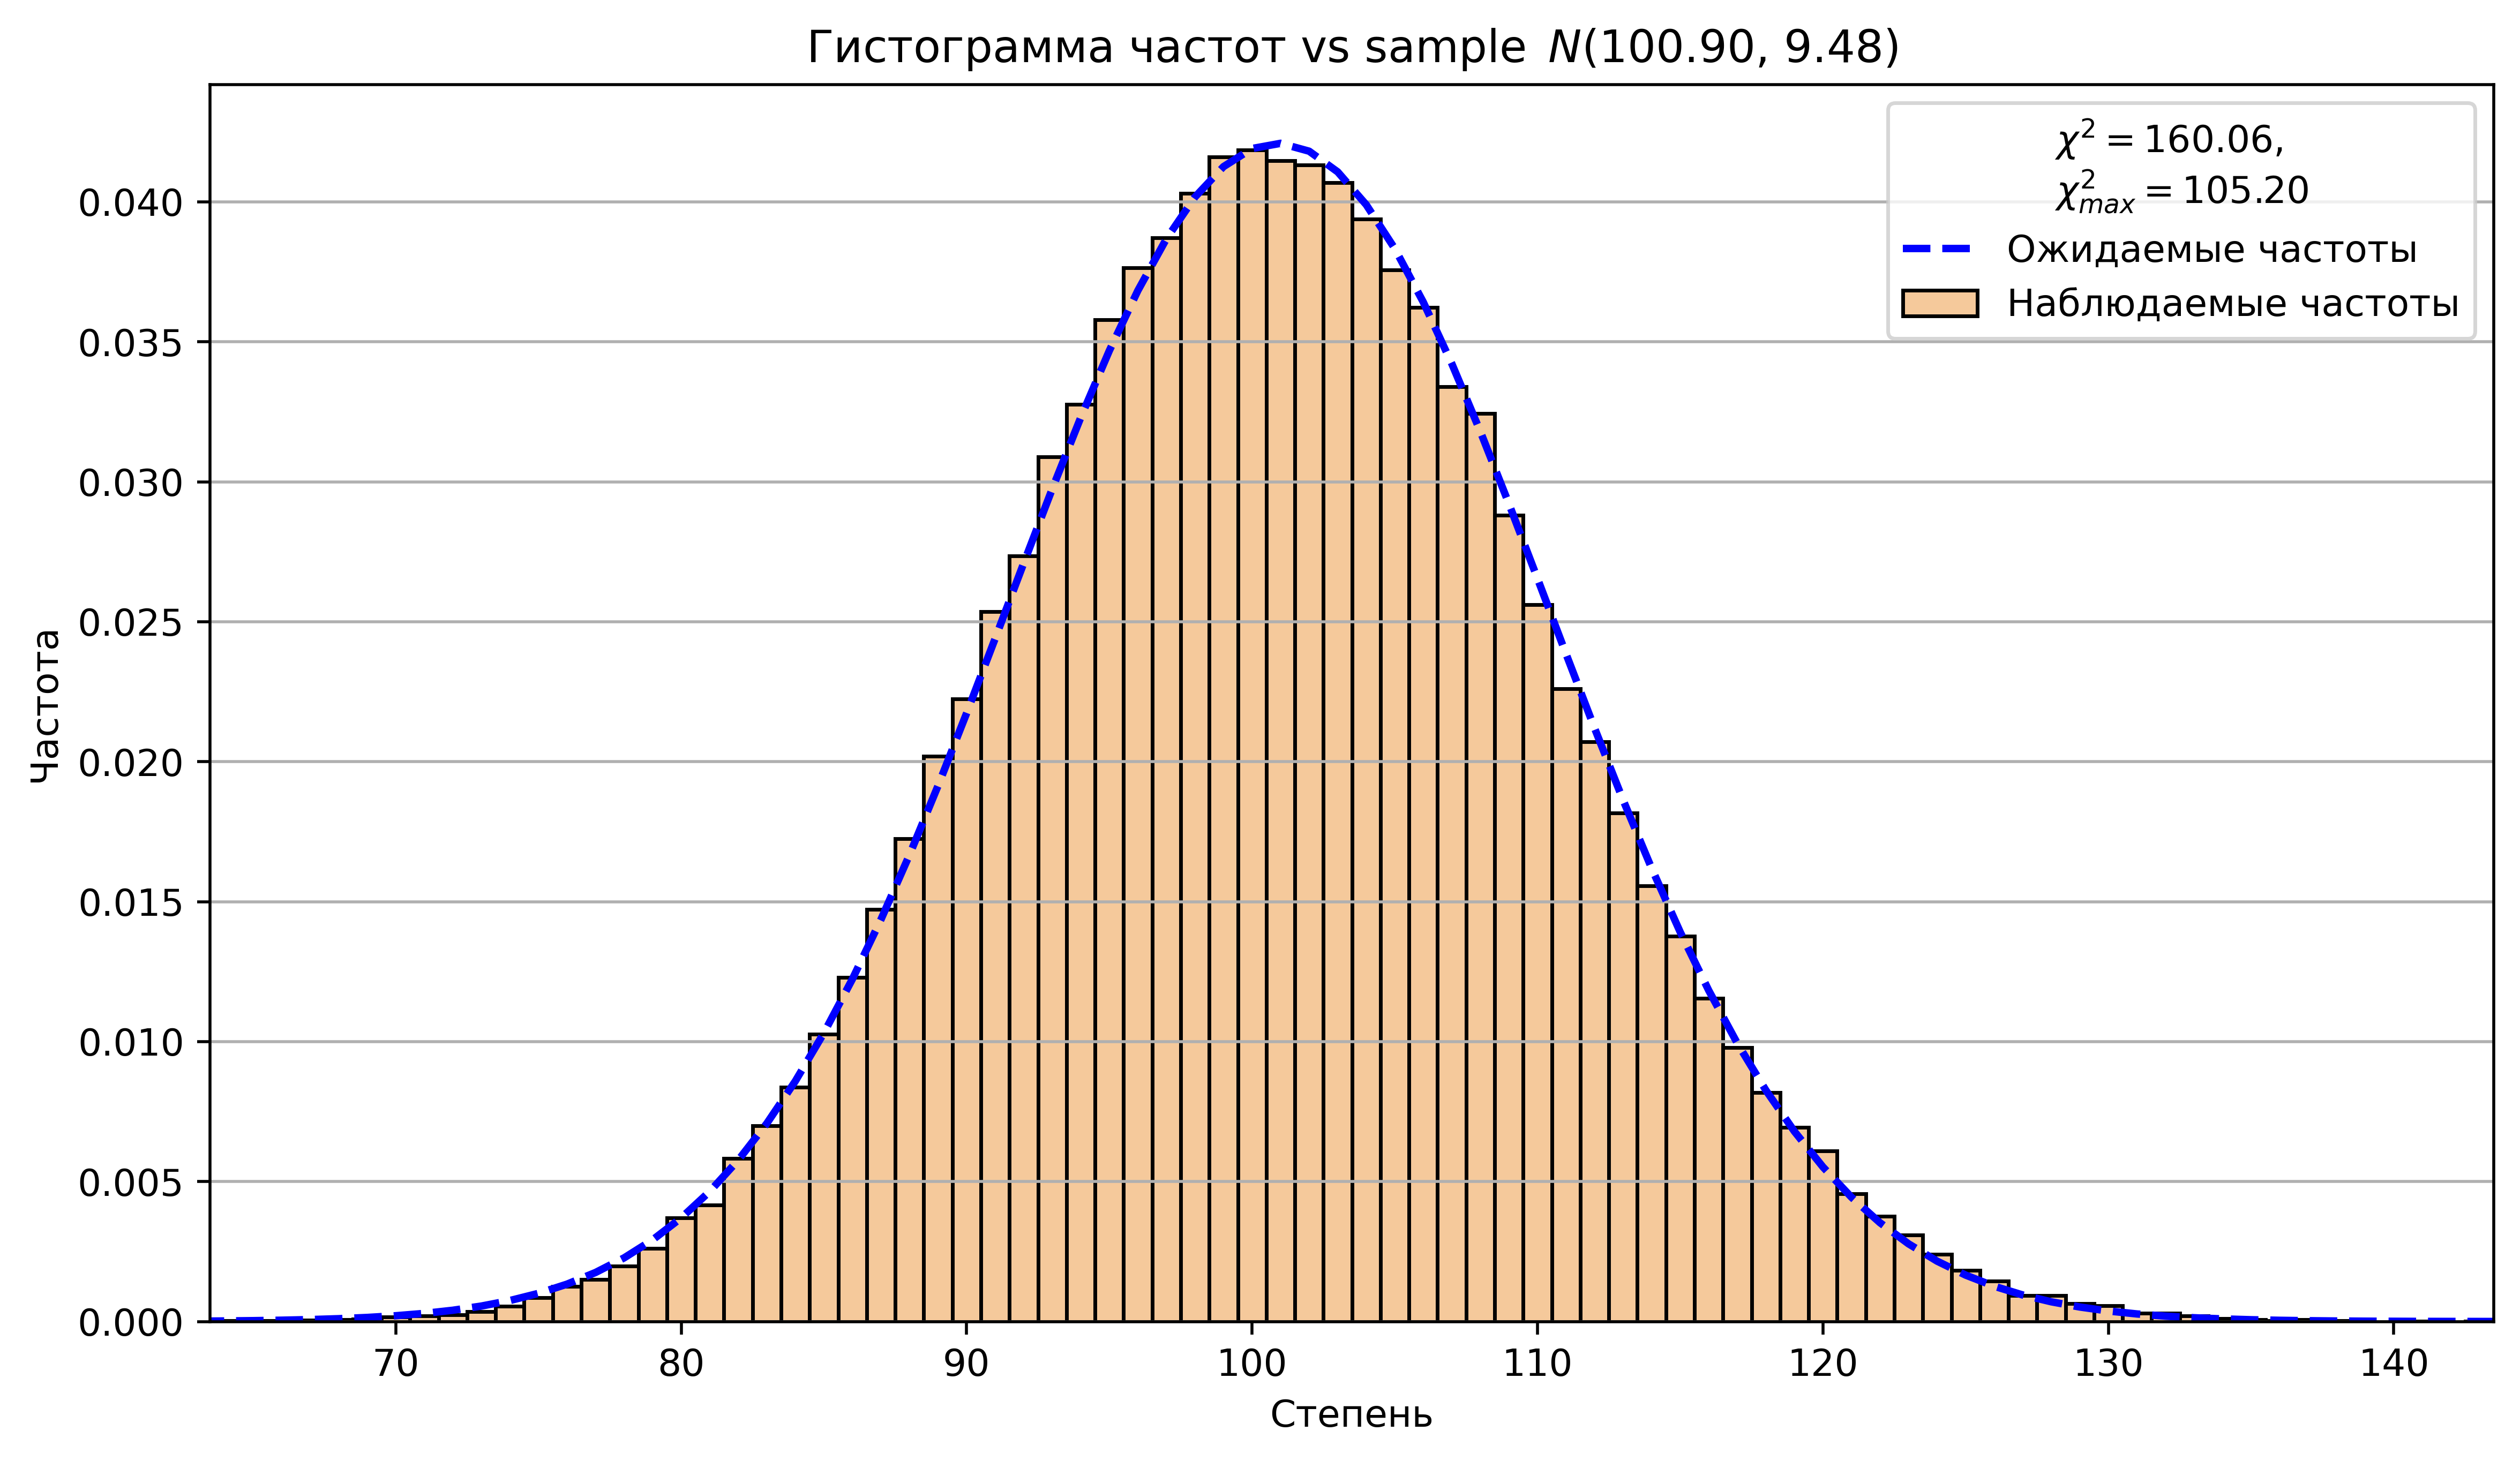

In [204]:
norm_xi2(degrees, deg)

In [4]:
# Функция для вычисления статистики хи-квадрат биномального распределения
def binomial_xi2(degrees, deg, labtext = 'Степень', isBar = False):
    degrees = np.arange(len(deg))
    # Оценка параметров биномиального распределения
    n = degrees.max()  # Максимальная степень как число испытаний
    p = np.sum(degrees * deg) / (n * np.sum(deg))  # Оценка вероятности успеха
    print("n =", n, "p =", p)
    # Вычисление ожидаемых частот по биномиальному распределению
    total_count = np.sum(deg)
    expected_freq = total_count * binom.pmf(degrees, n, p)

    # Коррекция малых значений, чтобы избежать деления на 0
    expected_freq[expected_freq < 1e-6] = 1e-6

    # Вычисление статистики хи-квадрат
    chi_statistic = np.sum((deg - expected_freq) ** 2 / expected_freq)

    # Число степеней свободы
    dfree = len([i for i in deg if i > 0]) - 2  # Отнимаем 1 за n и 1 за p

    # Критическое значение хи-квадрат при alpha=0.05
    alpha = 0.01
    chi_critical = chi2.ppf(1 - alpha, max(dfree, 1))

    chi_label = r"$\chi^2 = $" + f"{chi_statistic:.2f}, \n" + r"$\chi^2_{max} = $" + f"{chi_critical:.2f}"
    # Вывод результатов
    mean_binom = n * p
    std_dev_binom = np.sqrt(n * p * (1 - p))

    # Определяем границы по ненулевым значениям
    nonzero_indices = np.nonzero(deg)[0]
    xmin, xmax = nonzero_indices[0] - 0.5, nonzero_indices[-1] + 0.5

    plt.figure(figsize=(11, 6), dpi=500)  # 8x6 дюймов и 100 DPI
    # Визуализация результатов биномиального распределения

    if isBar == False:
        plt.bar(degrees, deg/sum(deg), width=1.0, align='center', color='#F5C99B', edgecolor='black', label="Наблюдаемые частоты", alpha = 0.7)
        plt.plot(degrees, expected_freq/sum(expected_freq), color='blue', linestyle='dashed', linewidth=2, label="Ожидаемые частоты", alpha = 1)
    else:
        plt.bar(degrees, deg/sum(deg), width=1.0, align='center', color='lightgreen', edgecolor='black', label="Наблюдаемые частоты", alpha = 0.7)
        plt.bar(degrees, expected_freq/sum(expected_freq), width=0.6, align='center', color='red', edgecolor='black', label="Ожидаемые частоты", alpha = 0.3)        


    plt.legend(title=chi_label)


    plt.xlabel('Степень')
    plt.ylabel('Частота')
    plt.title(r'Гистограмма частот vs sample $\,Bin$(' + f"{p:.2f}, {(n+3):.0f}" r')')
    plt.xlim([xmin, xmax])  # Устанавливаем границы оси X
    #print([xmin, xmax])
    plt.grid(axis='y')
    # Вывод легенды под график
    #plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), fancybox=True, shadow=True, ncol=2)
    plt.show()

    # Вывод результатов
    print(f"Среднее: {mean_binom:.2f}, СКО: {std_dev_binom:.2f}")
    print(f"Статистика критерия хи-квадрат: {chi_statistic:.2f}")
    print(f"Критическое значение хи-квадрат при на уровне значимости 1 - alpha = {1 - alpha}: {chi_critical:.2f}")

    # Проверка гипотезы
    if chi_statistic < chi_critical:
        print("Гипотеза о биномиальном распределении НЕ отвергается.")
    else:
        print("Гипотеза о биномиальном распределении отвергается.")
    

n = 996 p = 0.10130321285140562


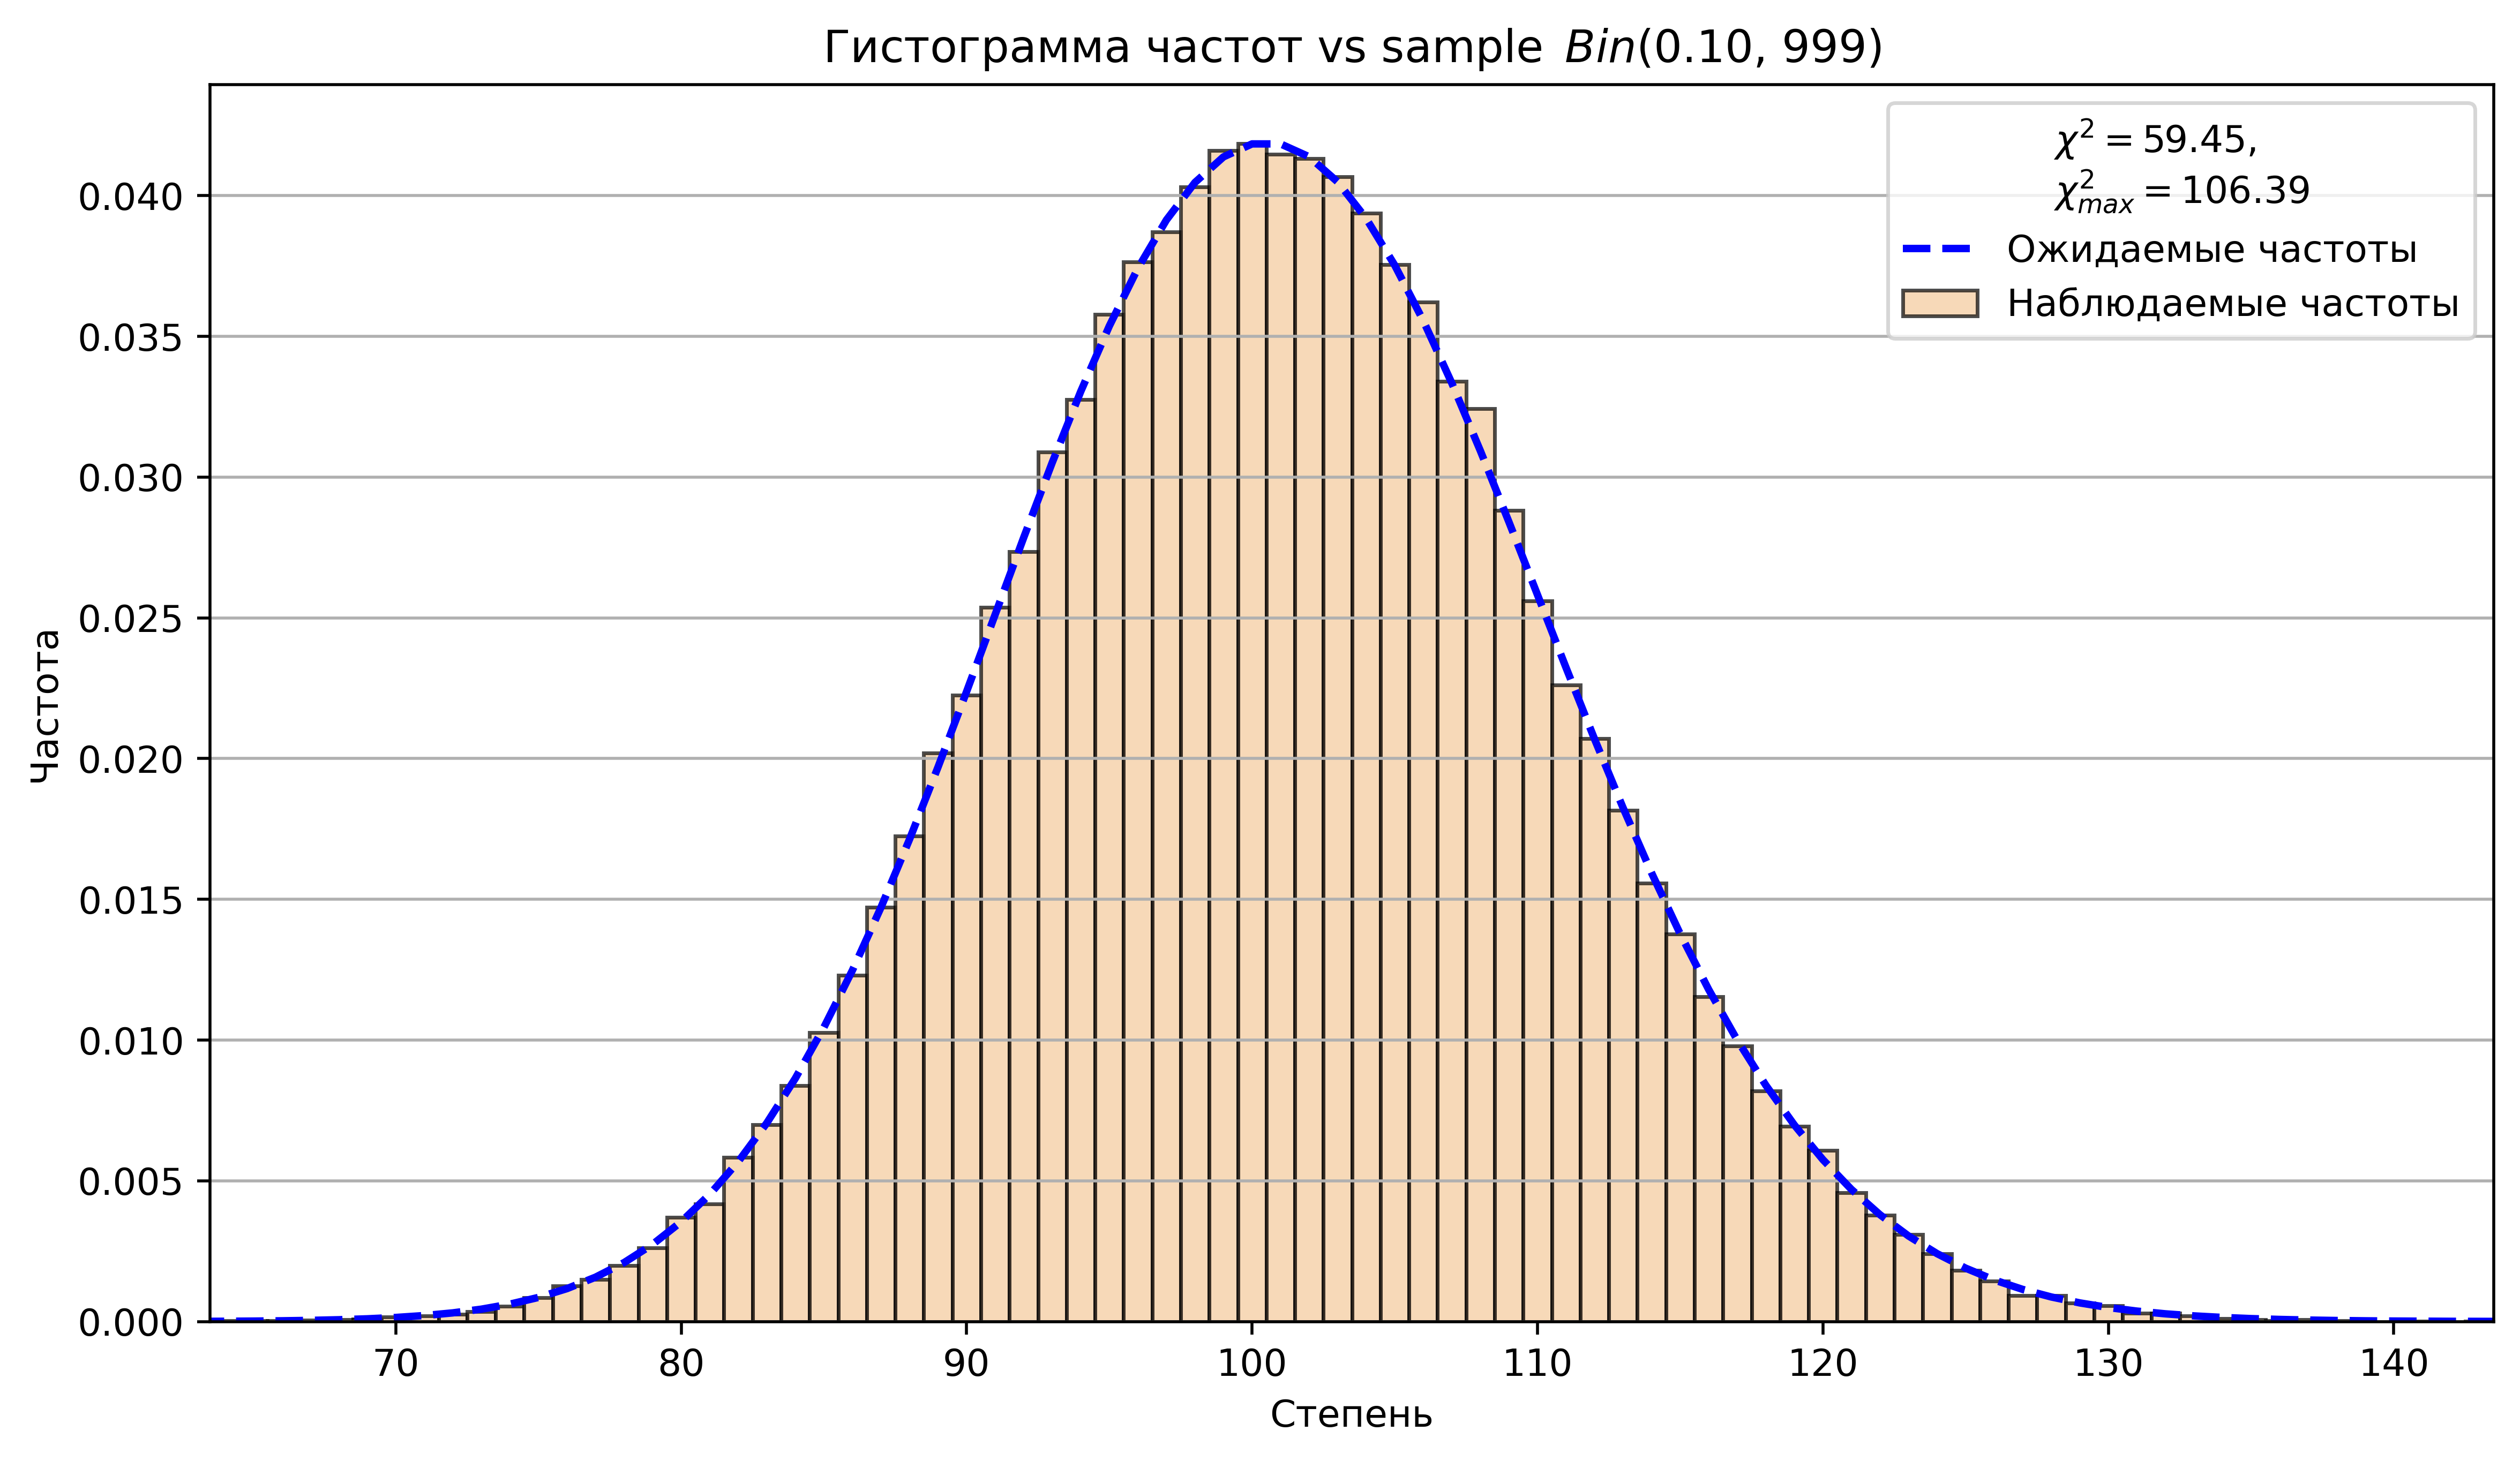

Среднее: 100.90, СКО: 9.52
Статистика критерия хи-квадрат: 59.45
Критическое значение хи-квадрат при на уровне значимости 1 - alpha = 0.99: 106.39
Гипотеза о биномиальном распределении НЕ отвергается.


In [206]:
binomial_xi2(degrees, deg)

# Анализ результатов Монте Карло

In [854]:
p = "10000"     # колчиество вершин
g = "10"        # количество графов
s = "1000"      # количество поисков в графе
di = "[0.0001]" # плотности
subprocess.run(["main.exe", p, g, s, di], check=True)

CompletedProcess(args=['main.exe', '10000', '10', '1000', '[0.0001]'], returncode=0)

In [6]:
# Чтение файла логов в датафрейм
df = pd.read_csv('fulllog.txt', sep='\s+', header=None, names=['p', 'Density', 'Distance', 'BFS_Result', 'DFS_Result'])

# Вычисление средних значений по плотности
averages_by_density = df.groupby('Density').agg({'BFS_Result': 'mean', 'DFS_Result': 'mean', 'Distance': 'mean', 'p': 'first'}).reset_index()
averages_by_density.rename(columns={'BFS_Result': 'BFS Avg', 'DFS_Result': 'DFS Avg', 'Distance': 'Distance Avg'}, inplace=True)

# Вычисление средних значений по (плотность, расстояние) с количеством пар
averages_by_density_distance = df.groupby(['Density', 'Distance']).agg({'BFS_Result': ['mean', 'count'], 'DFS_Result': 'mean', 'p': 'first'}).reset_index()
averages_by_density_distance.columns = ['Density', 'Distance', 'BFS Avg', 'Count', 'DFS Avg', 'p']
averages_by_density_distance['BFS/DFS'] = averages_by_density_distance['BFS Avg'] / averages_by_density_distance['DFS Avg']
averages_by_density_distance = averages_by_density_distance.dropna(subset=['BFS/DFS'])
averages_by_density = averages_by_density[['Density', 'p', 'BFS Avg', 'DFS Avg', 'Distance Avg']]
averages_by_density_distance = averages_by_density_distance[['Density', 'p', 'Distance', 'BFS Avg', 'DFS Avg', 'Count', 'BFS/DFS']]

print("Средние значения по плотности:")
print(averages_by_density)
final_df = averages_by_density_distance.copy()
final_df = final_df.sort_values(by=['p', 'Density'])
#final_df.set_index('Density', inplace=True)
final_df

Средние значения по плотности:
   Density     p      BFS Avg      DFS Avg  Distance Avg
0   0.0005  5000  2500.524060  2499.750776     11.261070
1   0.0010  5000  2498.862598  2498.377592      5.536982
2   0.0020  5000  2498.574360  2503.126598      3.951310
3   0.0040  5000  2500.905114  2505.340598      3.126108
4   0.0080  5000  2500.263778  2499.707408      2.711992
5   0.0160  5000  2502.256634  2504.194366      2.257706
6   0.0320  5000  2499.881682  2504.462280      1.973662
7   0.0640  5000  2496.814320  2504.101126      1.935592
8   0.1280  5000  2499.672840  2496.514965      1.872257


,Density,p,Distance,BFS Avg,DFS Avg,Count,BFS/DFS
0,0.0005,5000,1,3.056680,2449.834008,247,0.001248
1,0.0005,5000,2,7.684404,2757.822018,545,0.002786
2,0.0005,5000,3,18.839286,2569.188910,1064,0.007333
3,0.0005,5000,4,40.506540,2558.553000,2217,0.015832
4,0.0005,5000,5,84.842769,2570.024976,4204,0.033012
5,0.0005,5000,6,169.357580,2508.906931,8166,0.067503
6,0.0005,5000,7,328.313627,2525.251188,15359,0.130012
7,0.0005,5000,8,607.849780,2534.263680,28345,0.239853
8,0.0005,5000,9,1052.852018,2520.488204,47472,0.417717
9,0.0005,5000,10,1660.517957,2513.830698,70336,0.660553


Проанализируем распределение расстояний

C:\Users\skiva\AppData\Local\Temp\ipykernel_3708\1858020851.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data['Distance'] = filtered_data['Distance'].round().astype(int)


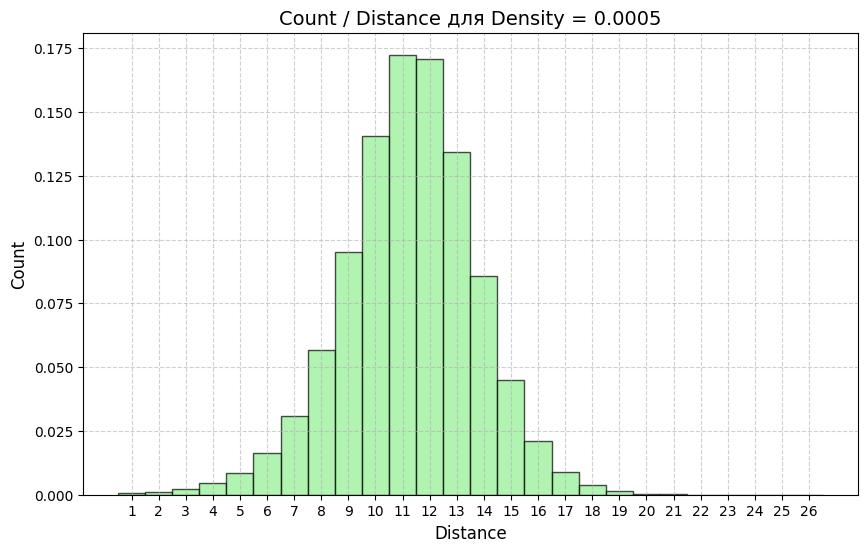

In [10]:
# Задаем плотность, для которой нужно построить гистограмму
target_density = 0.0005
filtered_data = averages_by_density_distance[averages_by_density_distance['Density'] == target_density]
filtered_data['Distance'] = filtered_data['Distance'].round().astype(int)

grouped_data = filtered_data.groupby('Distance')['Count'].sum()

plt.figure(figsize=(10, 6))
plt.bar(grouped_data.index, grouped_data.values / sum(grouped_data.values), width=1.0, align='center', color='lightgreen', edgecolor='black', label="Наблюдаемые частоты", alpha=0.7)

plt.xlabel('Distance', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title(f'Count / Distance для Density = {target_density}', fontsize=14)

plt.xticks(grouped_data.index)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

n = 25 p = 0.4104428


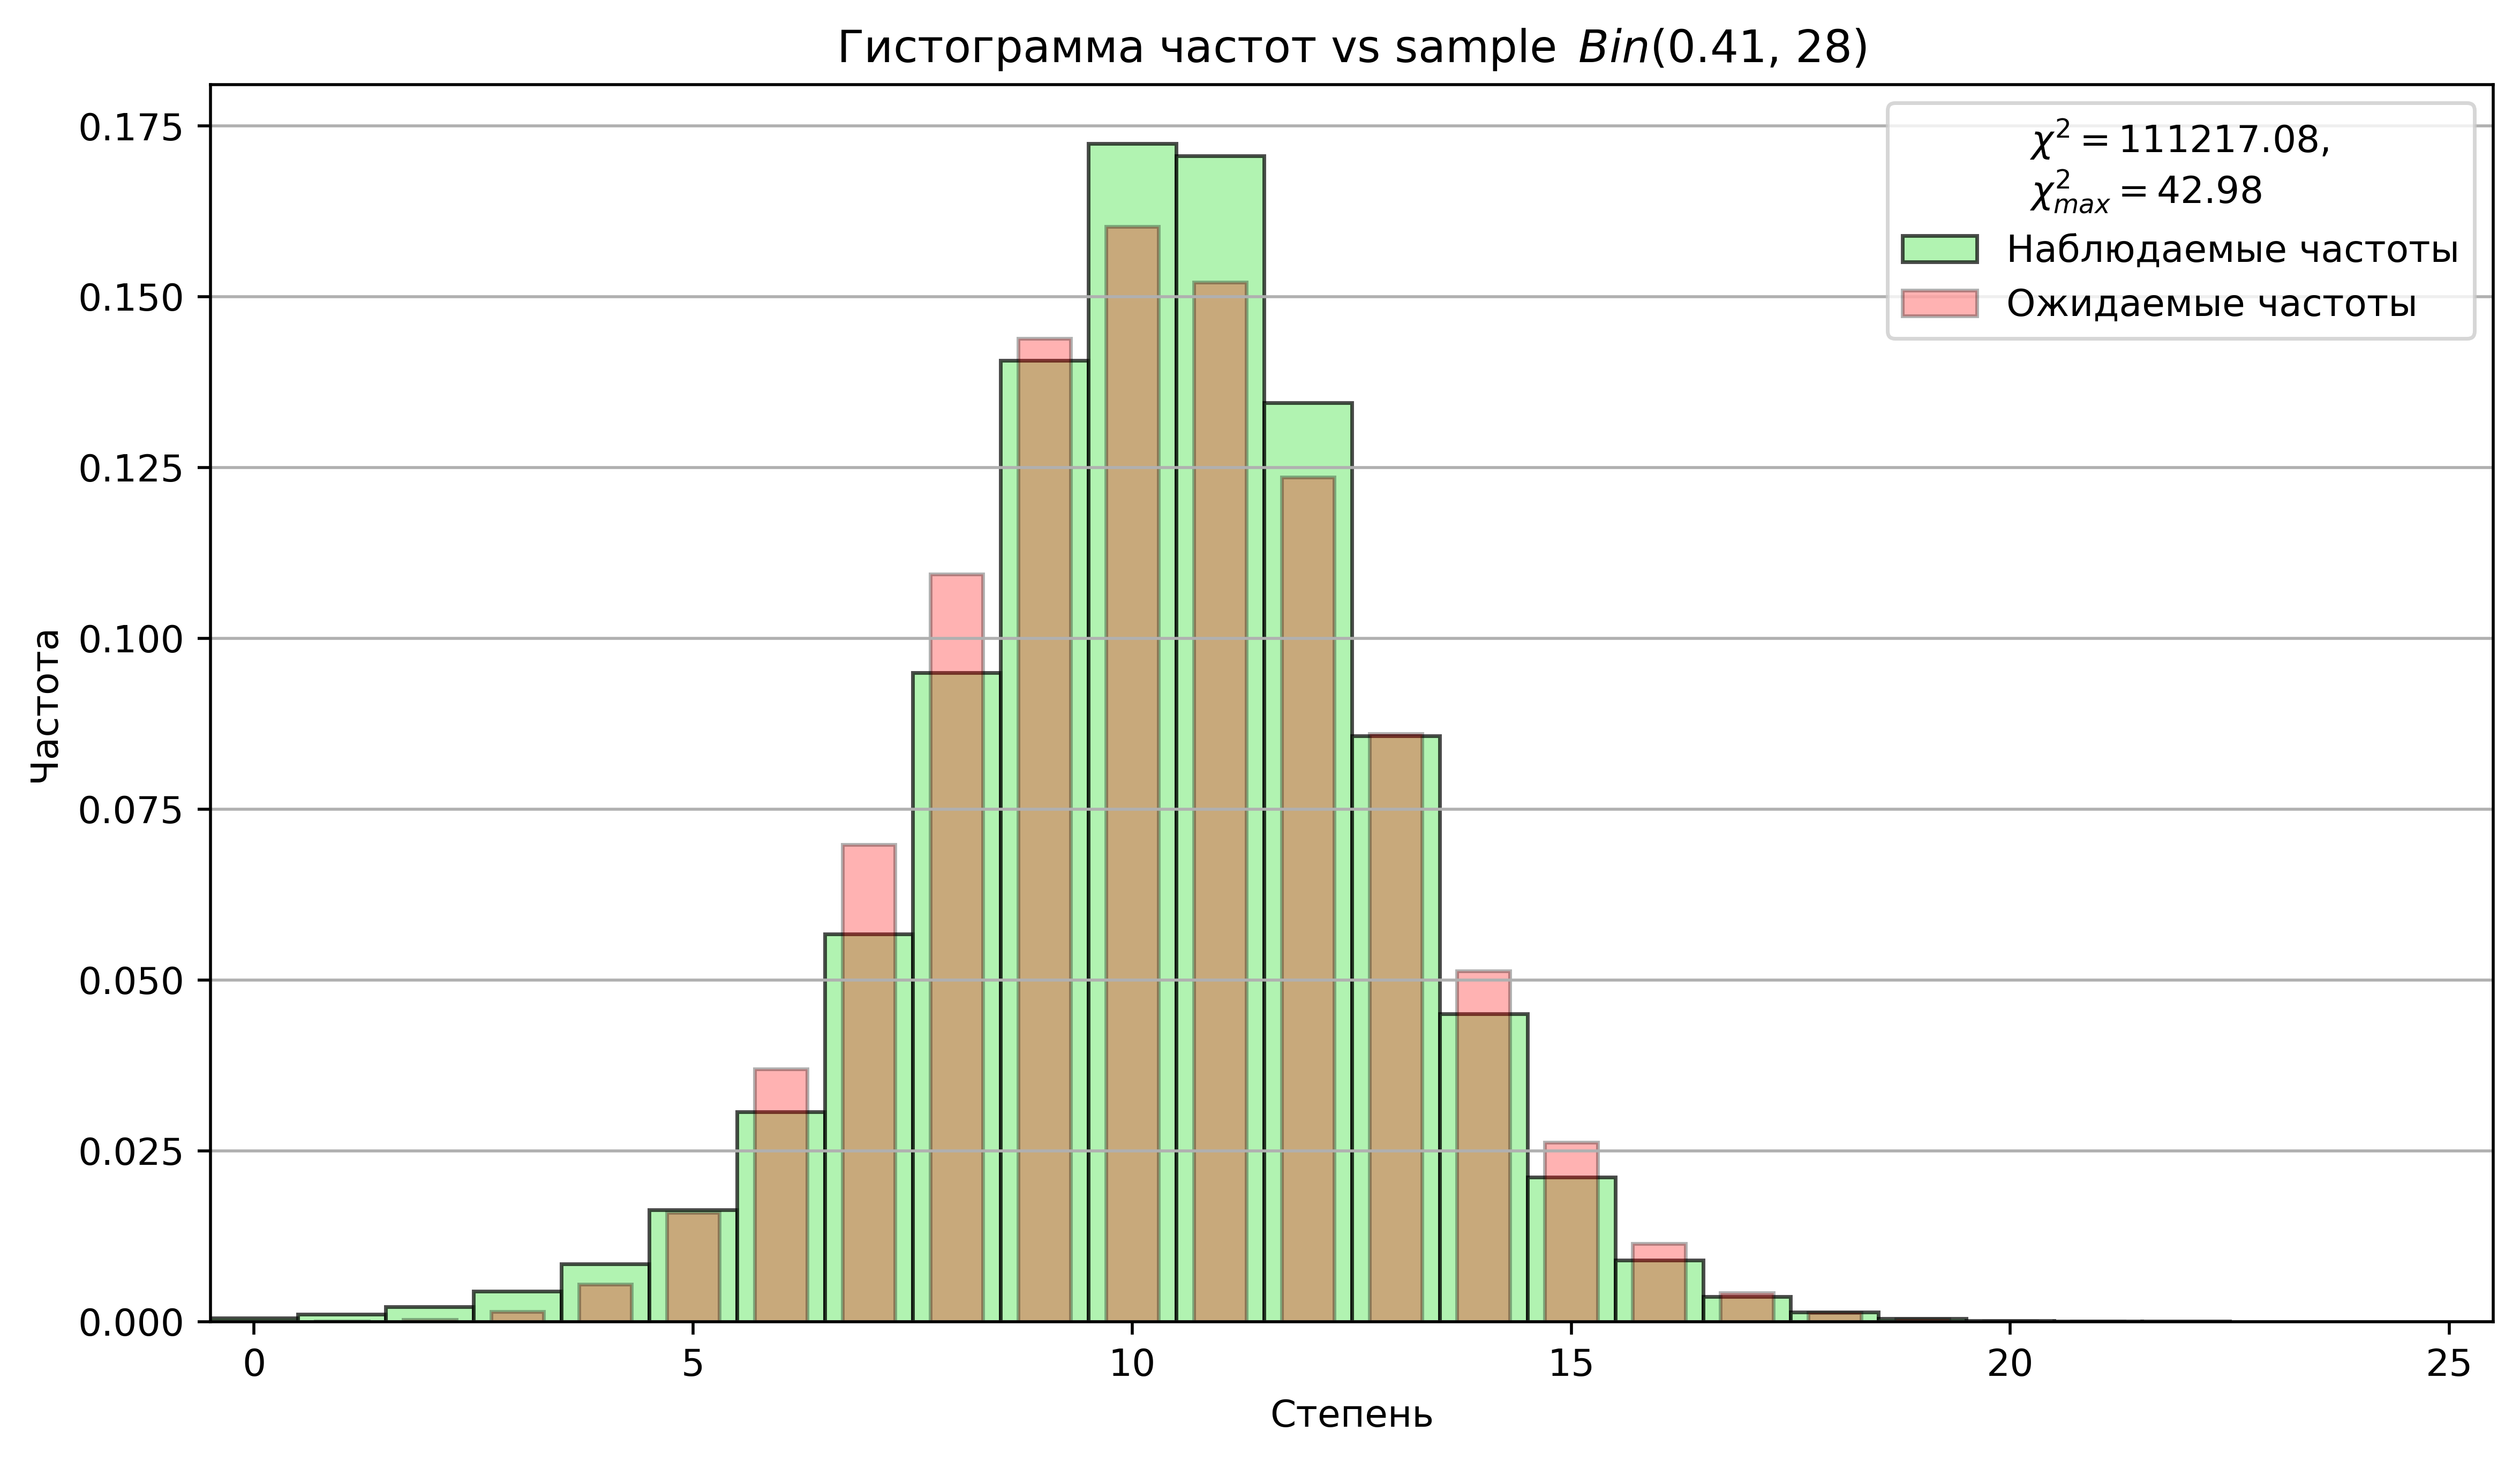

Среднее: 10.26, СКО: 2.46
Статистика критерия хи-квадрат: 111217.08
Критическое значение хи-квадрат при на уровне значимости 1 - alpha = 0.99: 42.98
Гипотеза о биномиальном распределении отвергается.


In [11]:
degrees = grouped_data.index
deg = grouped_data.values
binomial_xi2(degrees, deg, 'Расстояние', True)

Среднее: 10.26, СКО: 2.46
Статистика критерия хи-квадрат: 17187.41
Критическое значение хи-квадрат при alpha=0.01: 41.64
Гипотеза о нормальности отвергается.


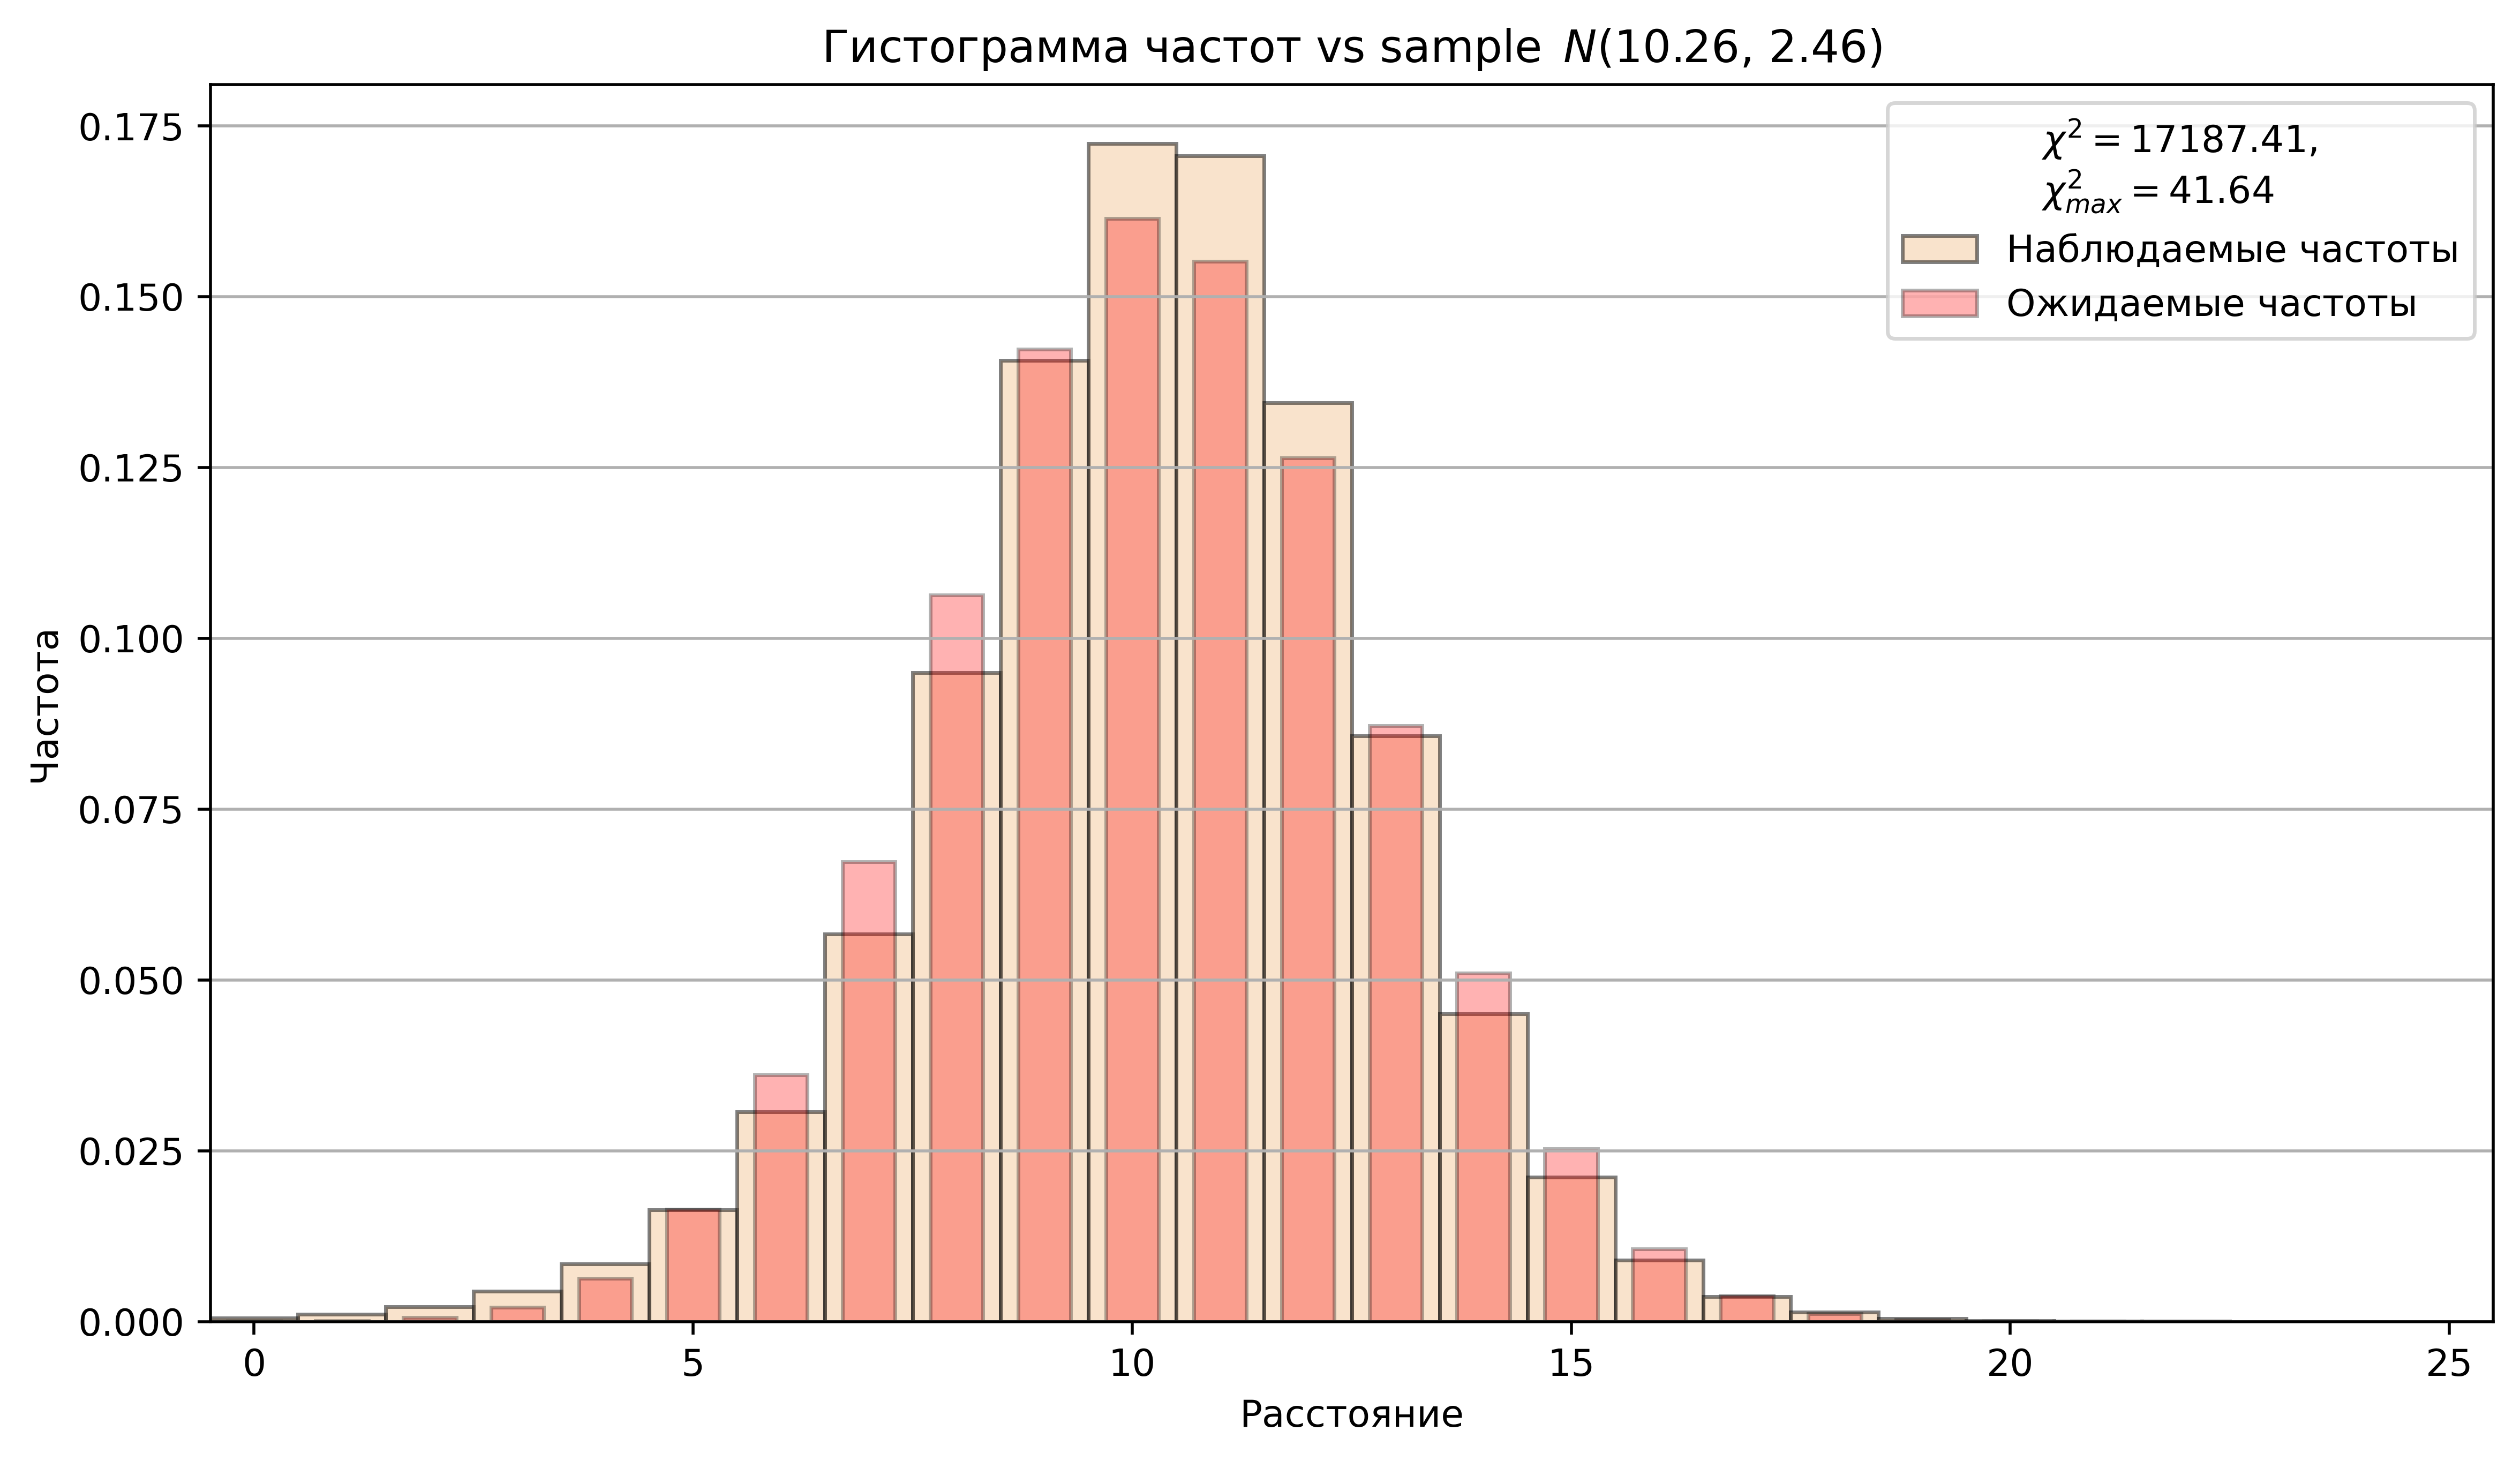

In [12]:
norm_xi2(degrees, deg, 'Расстояние', True)

 ### Построим график BFS и DFS от плотности

In [13]:
averages_by_density = df.groupby('Density').agg({'BFS_Result': 'mean', 'DFS_Result': 'mean'}).reset_index()
averages_by_density

,Density,BFS_Result,DFS_Result
0,0.0005,2500.524060,2499.750776
1,0.0010,2498.862598,2498.377592
2,0.0020,2498.574360,2503.126598
3,0.0040,2500.905114,2505.340598
4,0.0080,2500.263778,2499.707408
5,0.0160,2502.256634,2504.194366
6,0.0320,2499.881682,2504.462280
7,0.0640,2496.814320,2504.101126
8,0.1280,2501.647632,2499.056734
9,0.2560,2505.421868,2499.552432


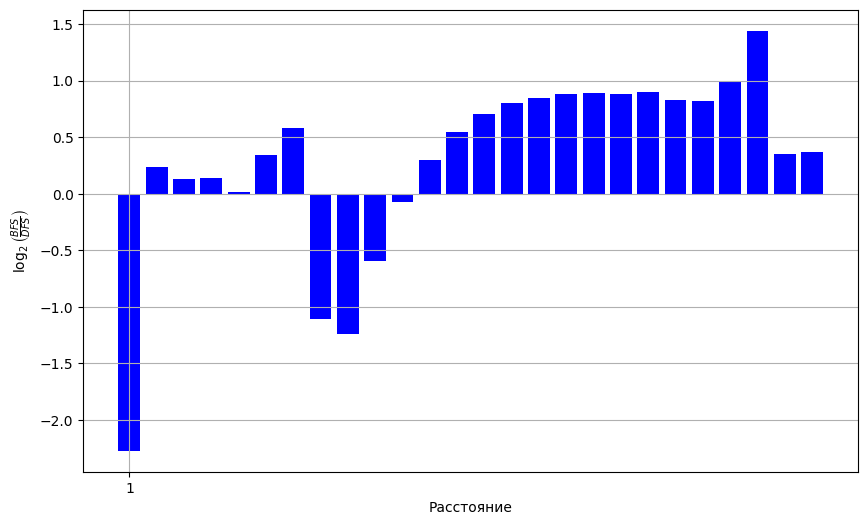

In [14]:
averages_by_dist = df.groupby(['Distance']).agg({'BFS_Result': 'mean', 'DFS_Result': 'mean'}).reset_index()
averages_by_dist['BFS/DFS_Ratio_Log'] = np.log2(averages_by_dist['BFS_Result'] / averages_by_dist['DFS_Result'])

plt.figure(figsize=(10, 6))
plt.bar(averages_by_dist['Distance'], averages_by_dist['BFS/DFS_Ratio_Log'], color = 'blue')
plt.xlabel('Расстояние')
plt.ylabel('$\\log_2{\\left( \\frac{BFS}{DFS} \\right)}$')
plt.title('')
plt.grid()
step = 50 # Шаг между метками
plt.xticks(averages_by_dist['Distance'][::step])  # Убираем метки для промежуточных значений
plt.show()

In [15]:
averages_by_dist_density = df.groupby(['Distance', 'Density']).agg({'BFS_Result': 'mean', 'DFS_Result': 'mean'}).reset_index()
averages_by_dist_density['BFS/DFS_Ratio_Log'] = np.log2(averages_by_dist_density['BFS_Result'] / averages_by_dist_density['DFS_Result'])

averages_by_dist_density_grouped = averages_by_dist_density.groupby(['Distance']).agg({'BFS/DFS_Ratio_Log':'mean'}).reset_index()
averages_by_dist_density_grouped

,Distance,BFS/DFS_Ratio_Log
0,1,-6.460039
1,2,-2.144486
2,3,-1.685752
3,4,-1.281195
4,5,-1.571701
5,6,-0.760684
6,7,-1.022815
7,8,-0.515209
8,9,-0.134368
9,10,1.518041


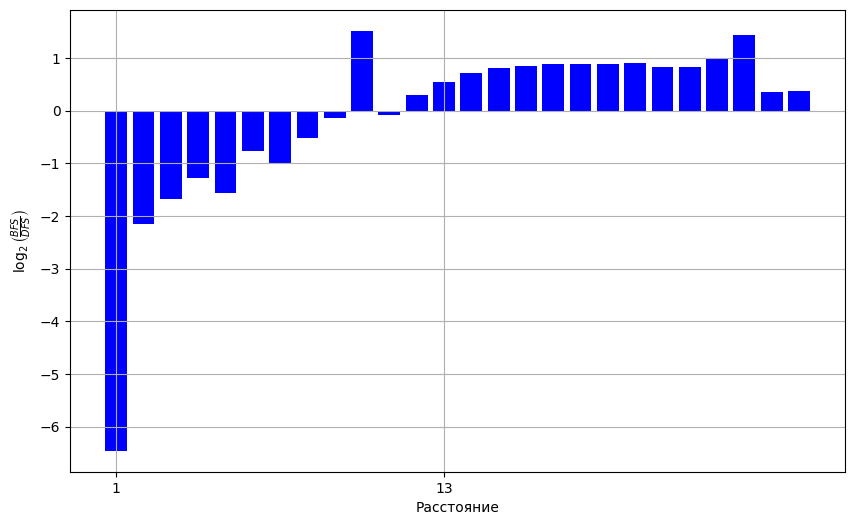

In [16]:
plt.figure(figsize=(10, 6))
plt.bar(averages_by_dist_density_grouped['Distance'], averages_by_dist_density_grouped['BFS/DFS_Ratio_Log'], color = 'blue')
plt.xlabel('Расстояние')
plt.ylabel('$\\log_2{\\left( \\frac{BFS}{DFS} \\right)}$')
plt.title('')
plt.grid()
step = 50 # Шаг между метками
plt.xticks(averages_by_dist_density['Distance'][::step])  # Убираем метки для промежуточных значений
plt.show()

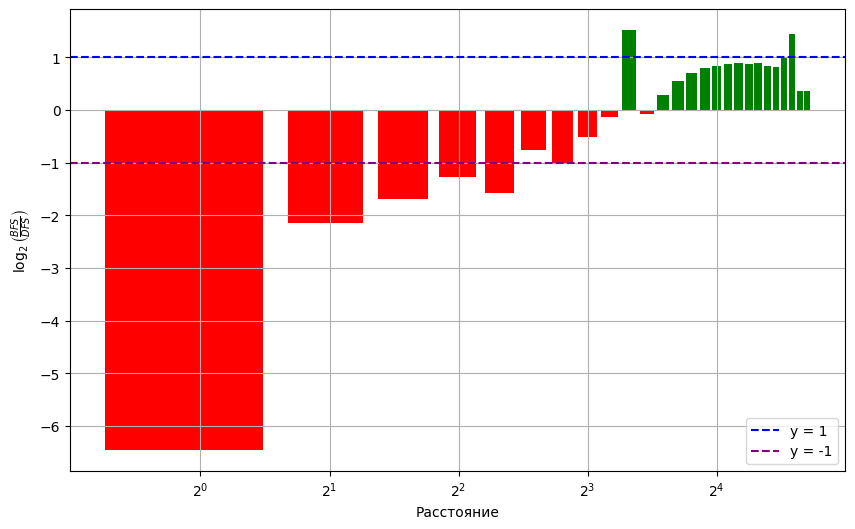

In [17]:
plt.figure(figsize=(10, 6))
positive_mask = averages_by_dist_density_grouped['BFS/DFS_Ratio_Log'] > 0
plt.bar(averages_by_dist_density_grouped['Distance'], averages_by_dist_density_grouped['BFS/DFS_Ratio_Log'], color='r')
plt.bar(averages_by_dist_density_grouped['Distance'][positive_mask], averages_by_dist_density_grouped['BFS/DFS_Ratio_Log'][positive_mask], color='g')
plt.xlabel('Расстояние')
plt.ylabel('$\\log_2{\\left( \\frac{BFS}{DFS} \\right)}$')
plt.title('')
plt.xscale('log', base=2)
step = 1  # Шаг между метками
ticks = [2**i for i in range(int(np.log2(averages_by_dist_density_grouped['Distance'].max())) + 1)]
plt.xticks(ticks)
plt.grid()

plt.axhline(y=1, color='b', linestyle='--', label='y = 1')
plt.axhline(y=-1, color='purple', linestyle='--', label='y = -1')

plt.legend()
plt.show()

Но здесь используется очень грубое усреднение по плотности, которое, в общем случае, может быть некооректно в силу неболшой вероятности того, что MC сошелся на небольшом количестве попаданий в заданное расстояние.

Поэтому отдельно есть смысл построить графики для каждой из исследуемых плотносте

In [19]:
log_ratios_by_density = averages_by_dist_density.pivot(index='Distance', columns='Density', values='BFS/DFS_Ratio_Log')
log_ratios_by_density.reset_index(inplace=True)

log_ratios_by_density

Density,Distance,0.0005,0.001,0.002,0.004,0.008,0.016,0.032,0.064,0.128,0.256,0.512
0,1,-9.646503,-9.858150,-9.318701,-8.629848,-7.785544,-6.864481,-5.899367,-4.901823,-3.856306,-2.766158,-1.533547
1,2,-8.487380,-7.036521,-5.330921,-3.546712,-1.789622,-0.412601,0.080791,0.180970,0.371717,0.754162,1.626775
2,3,-7.091425,-4.662763,-2.156496,-0.192698,0.376683,0.828100,1.098333,NaN,NaN,NaN,NaN
3,4,-5.981029,-2.515052,0.041278,0.864831,1.183997,NaN,NaN,NaN,NaN,NaN,NaN
4,5,-4.920847,-0.711040,0.916783,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,6,-3.888914,0.390345,1.216519,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,7,-2.943280,0.897650,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,8,-2.059780,1.029361,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,9,-1.259401,0.990664,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,10,-0.598254,3.634337,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


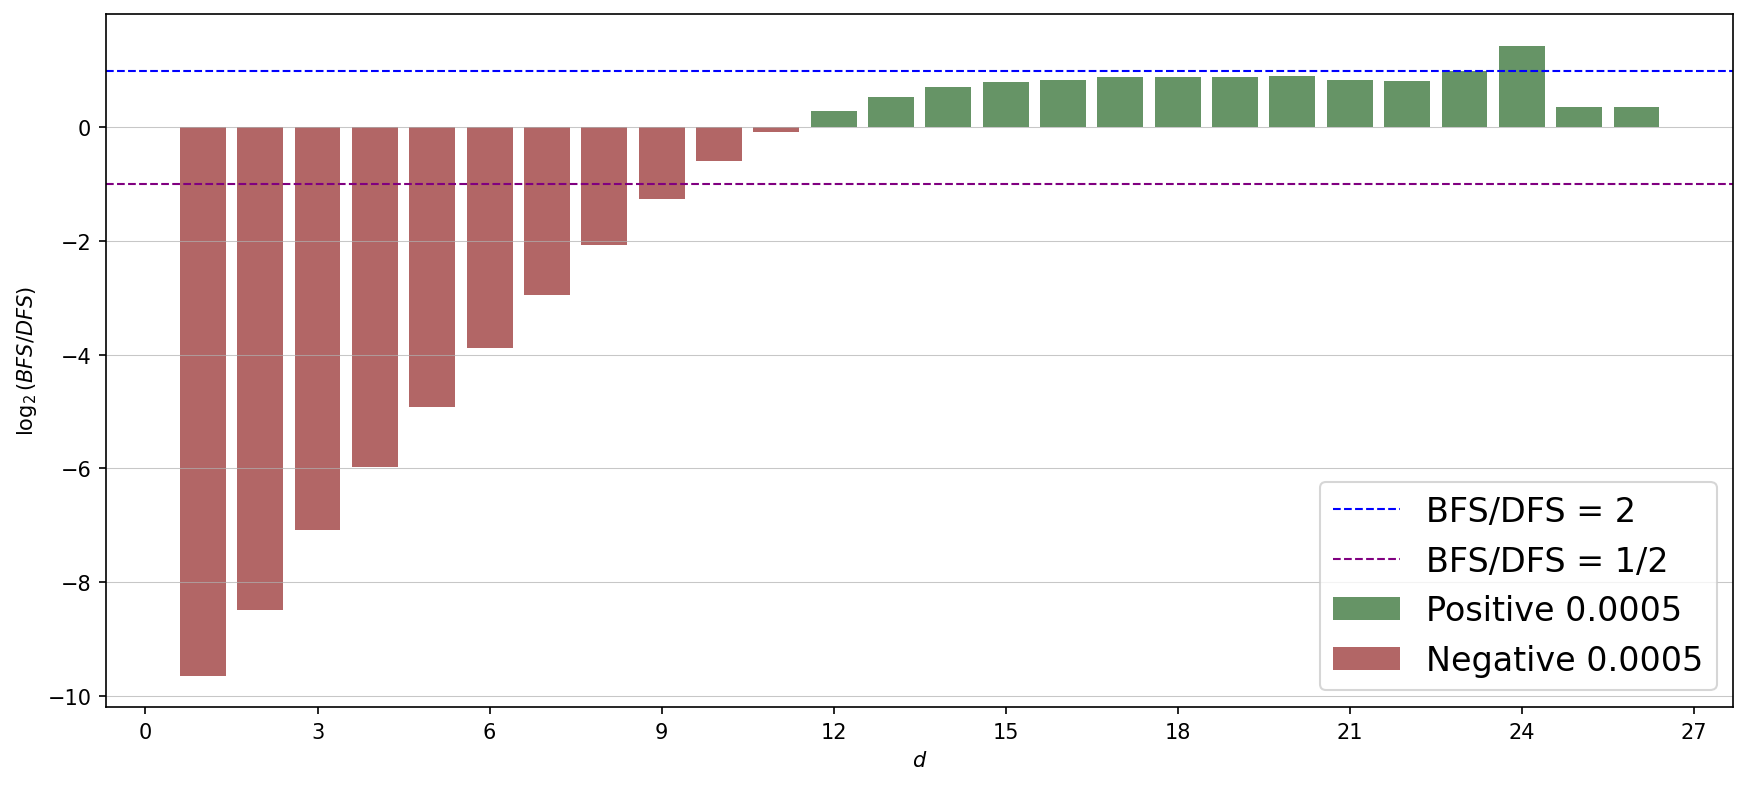

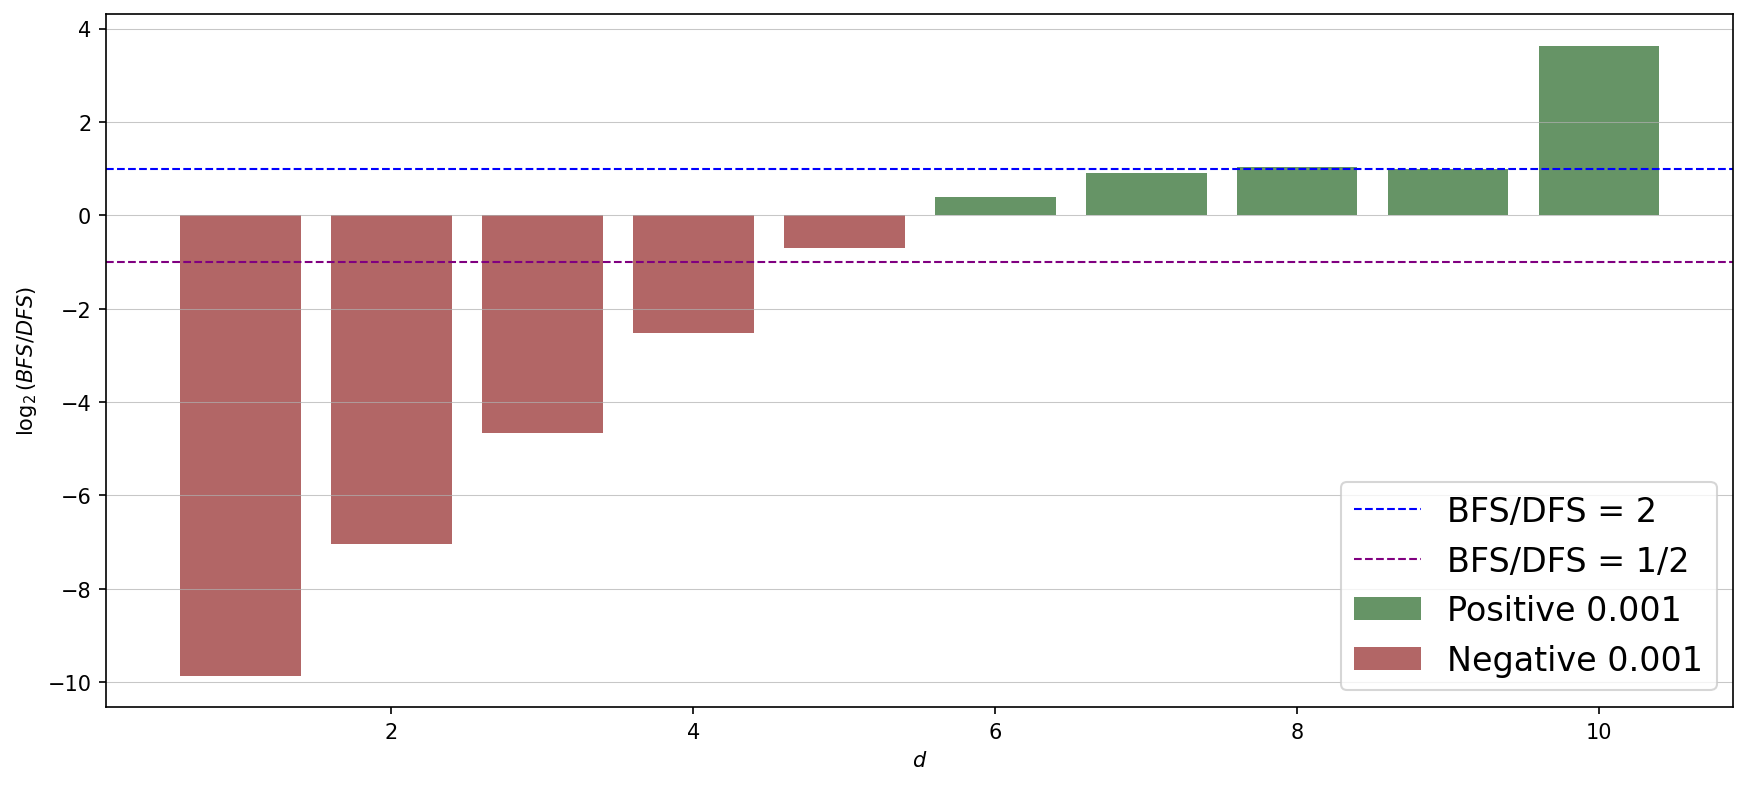

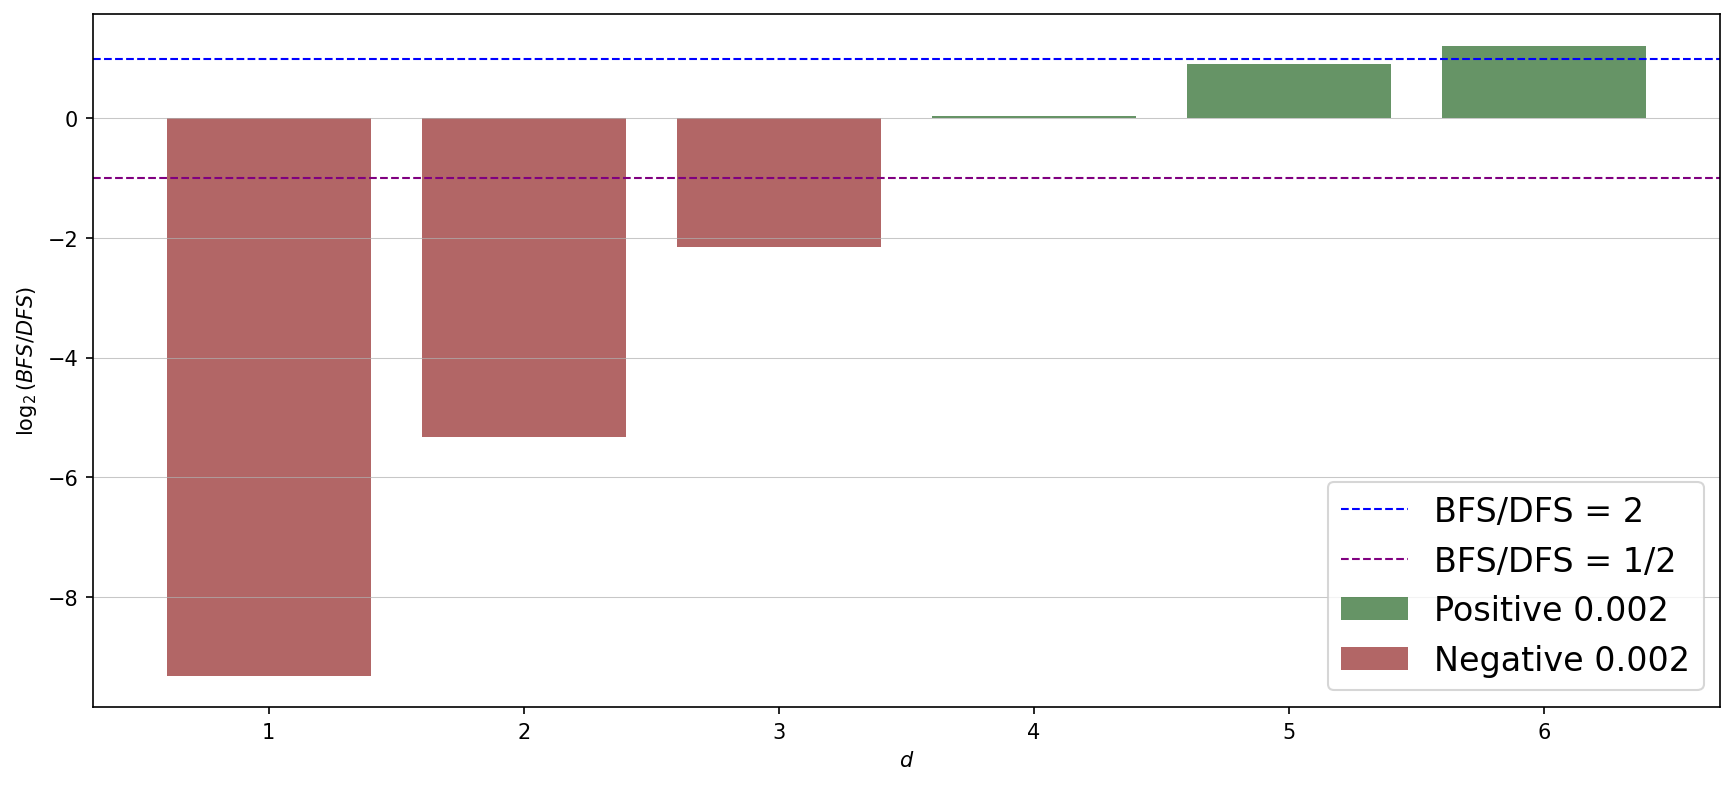

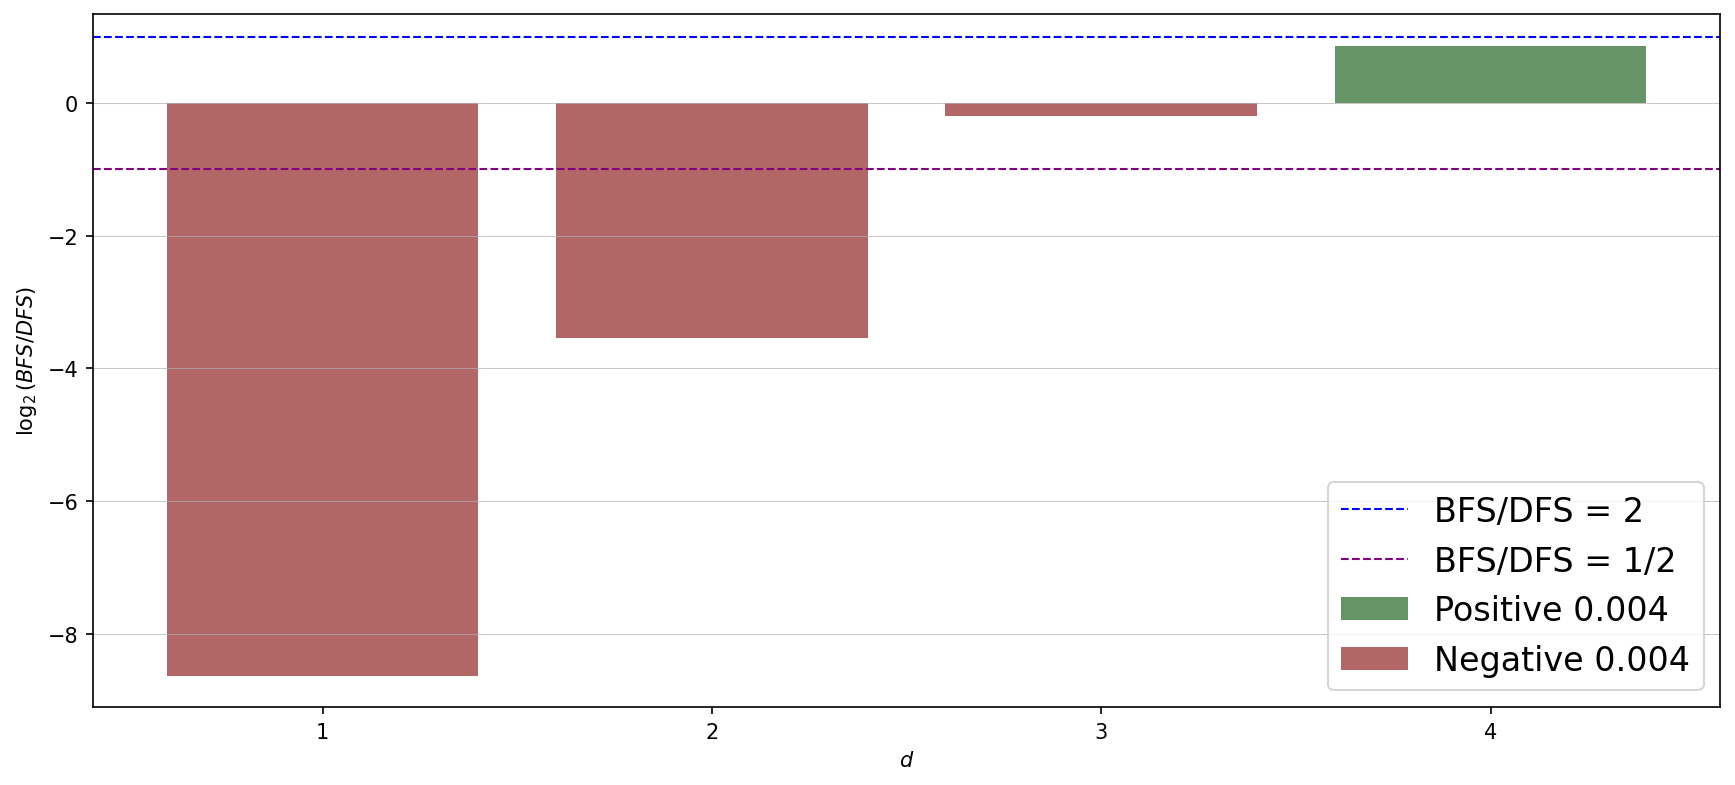

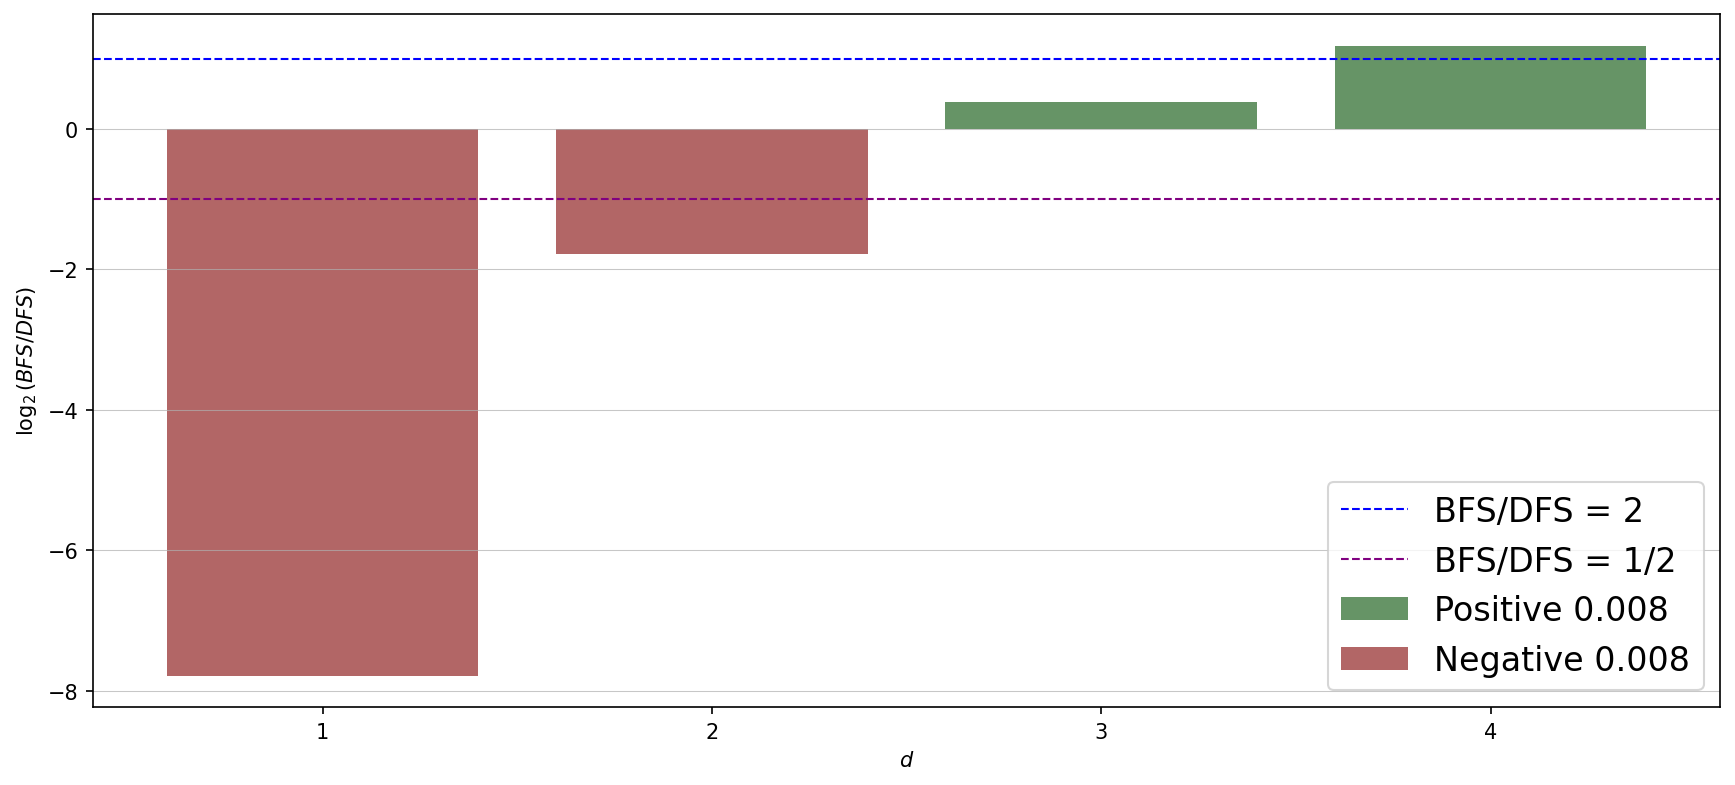

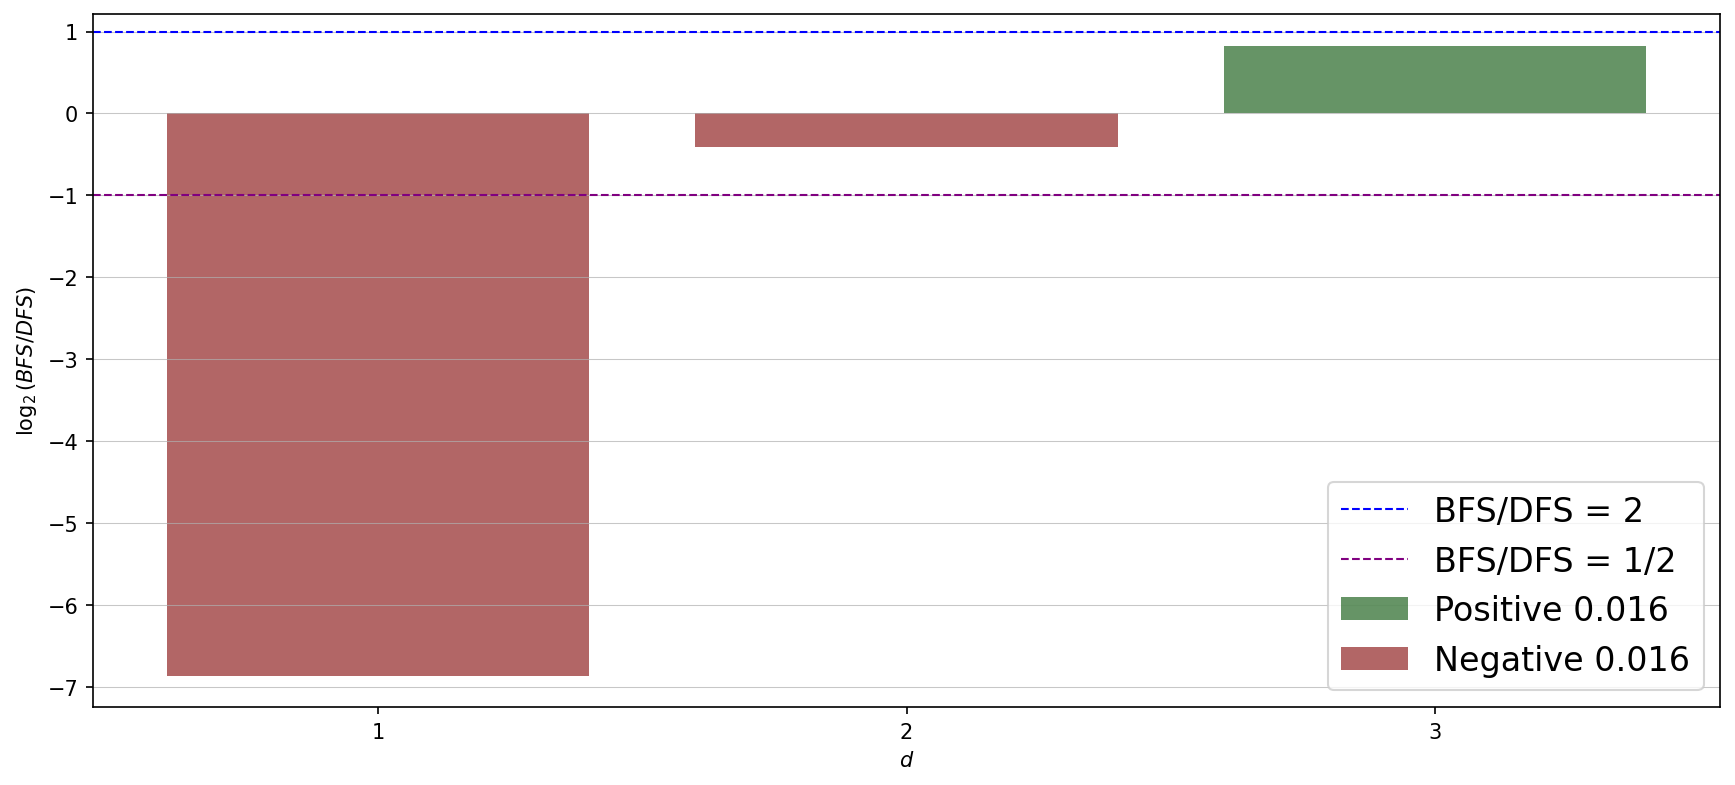

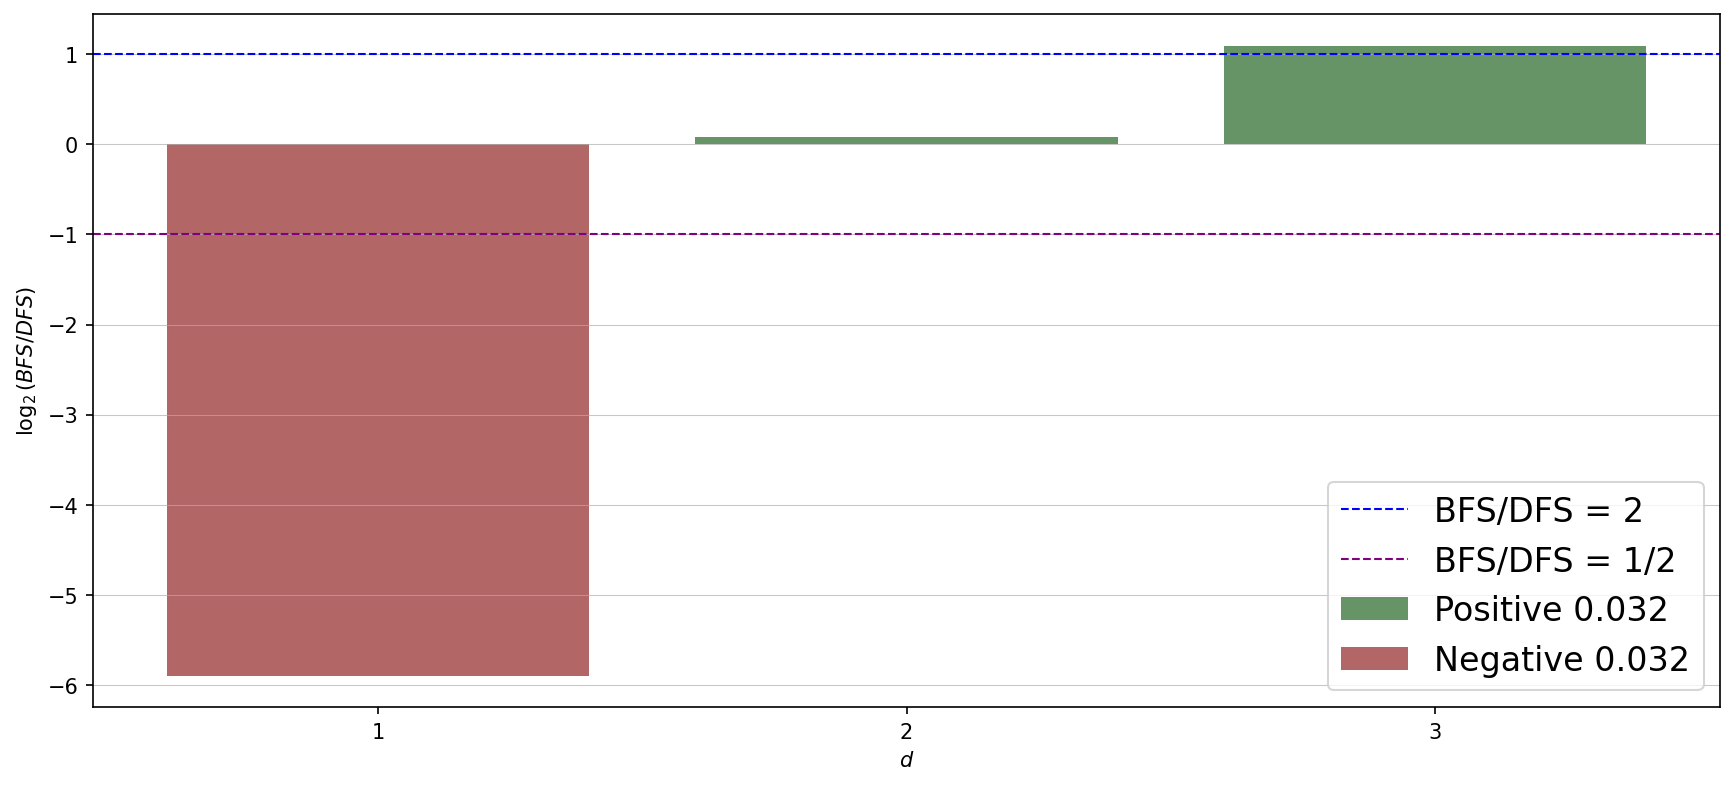

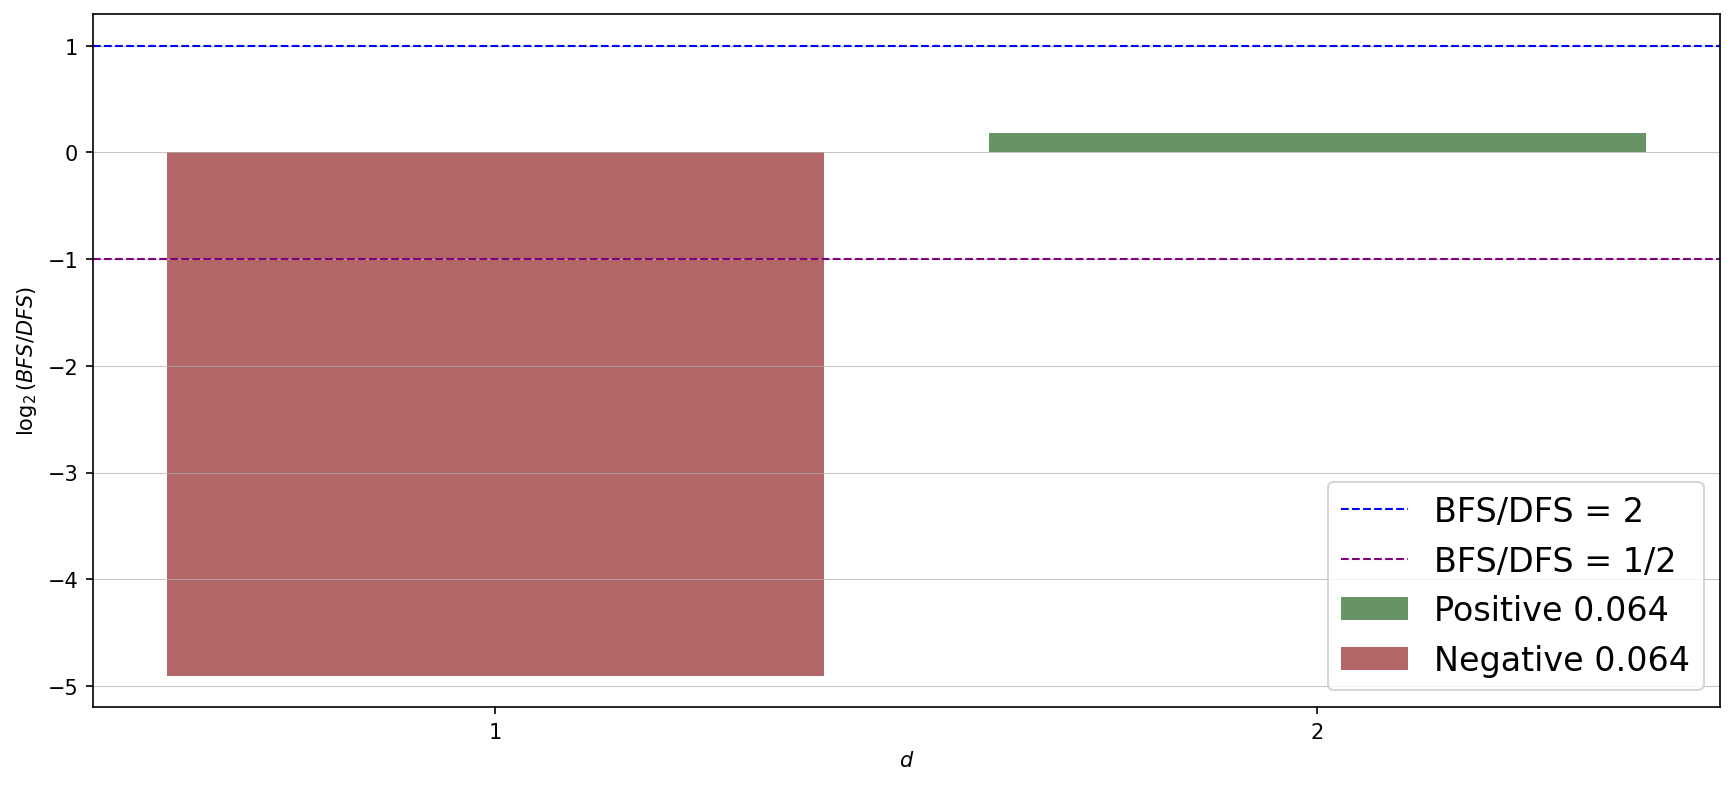

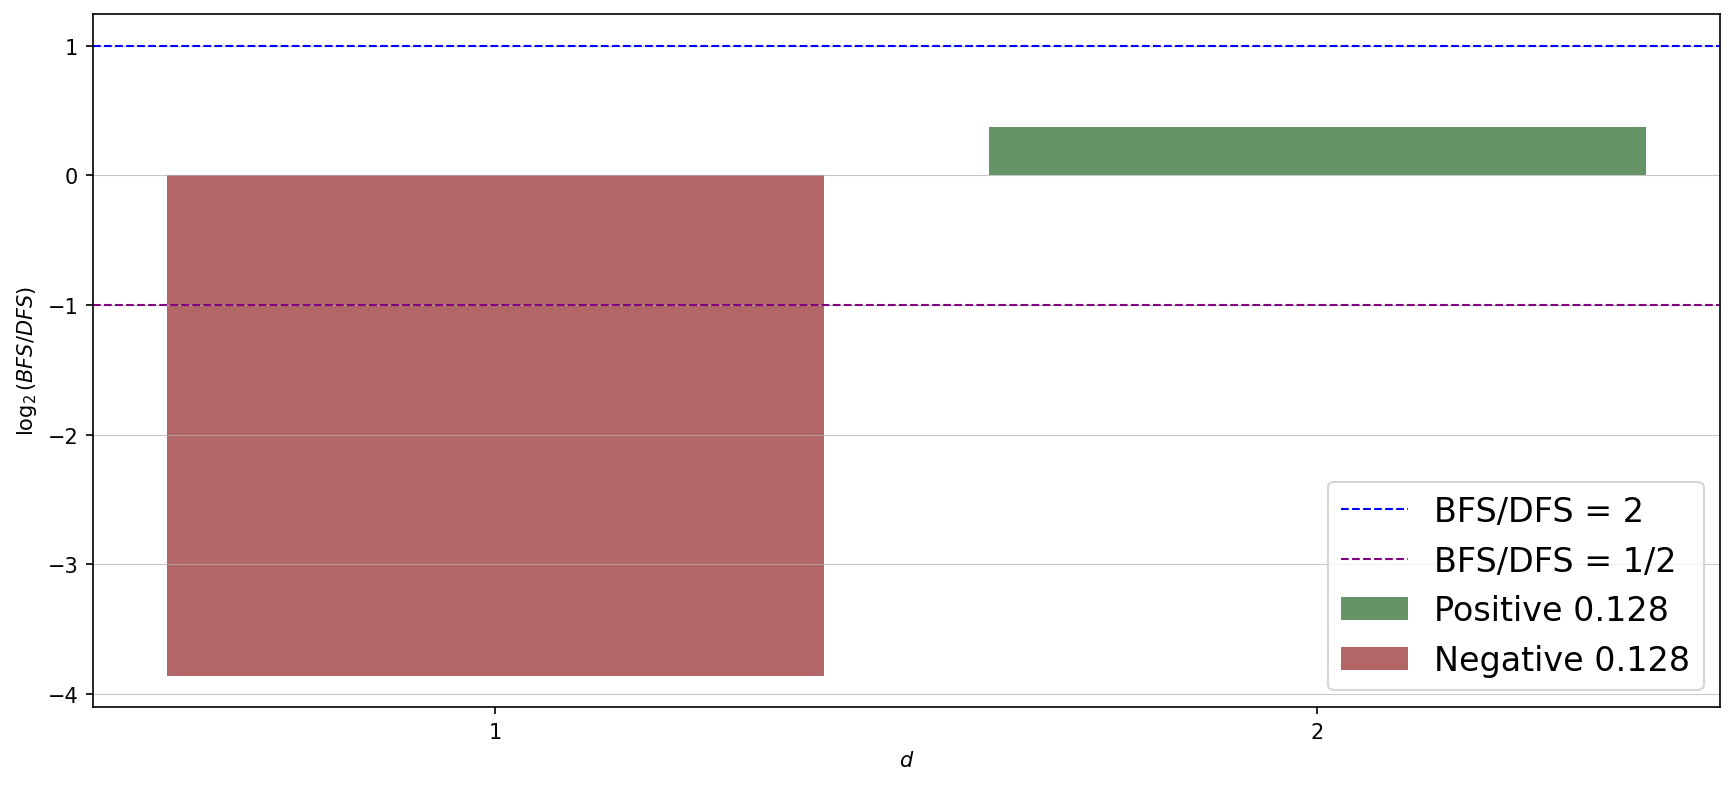

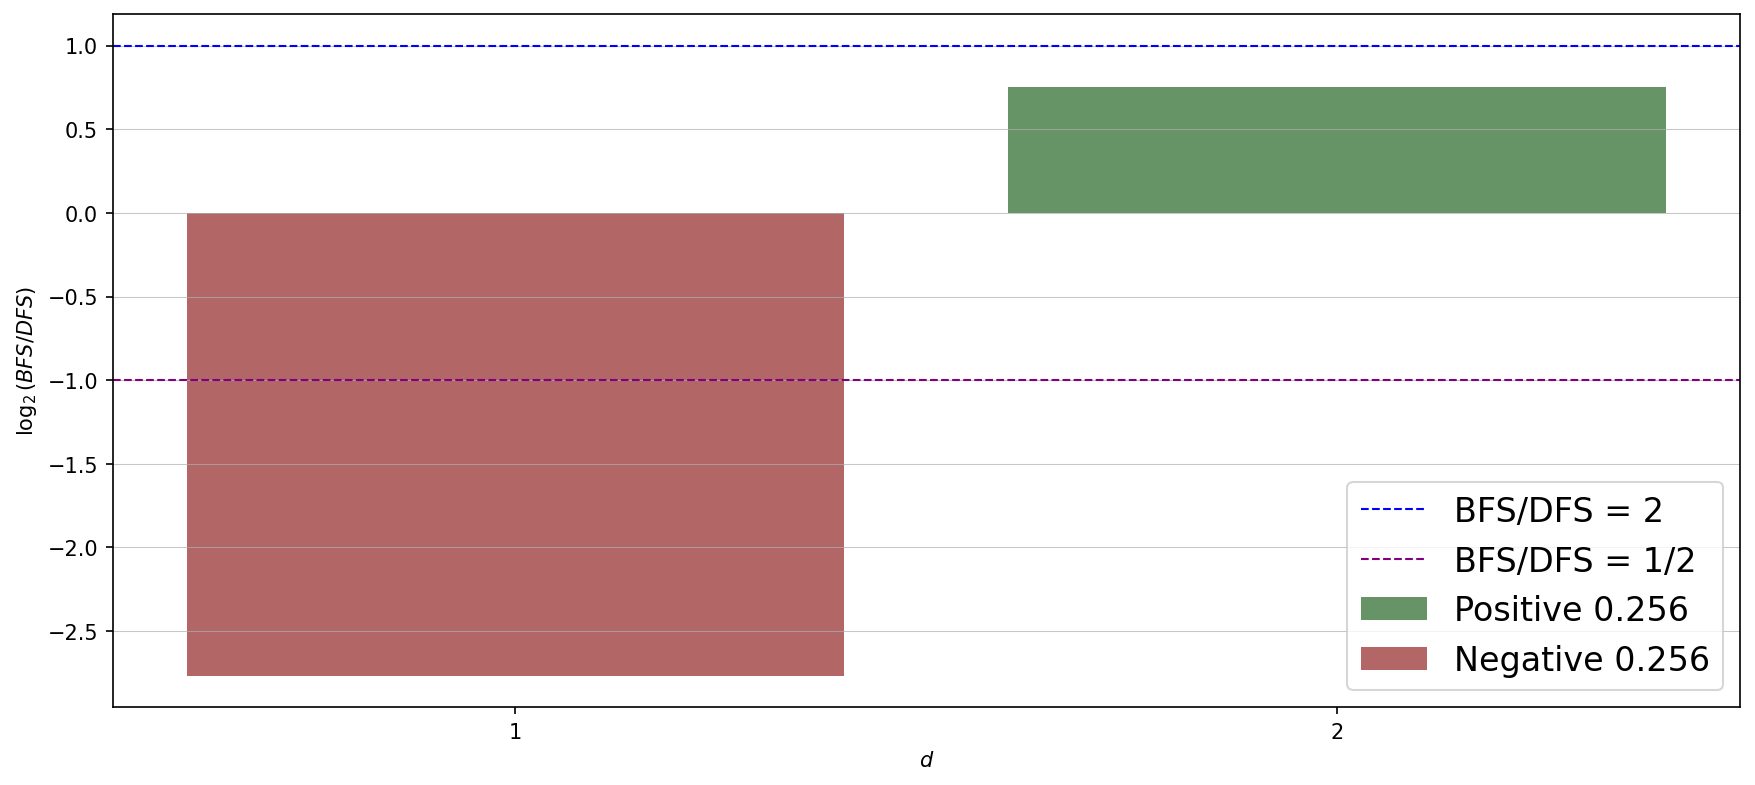

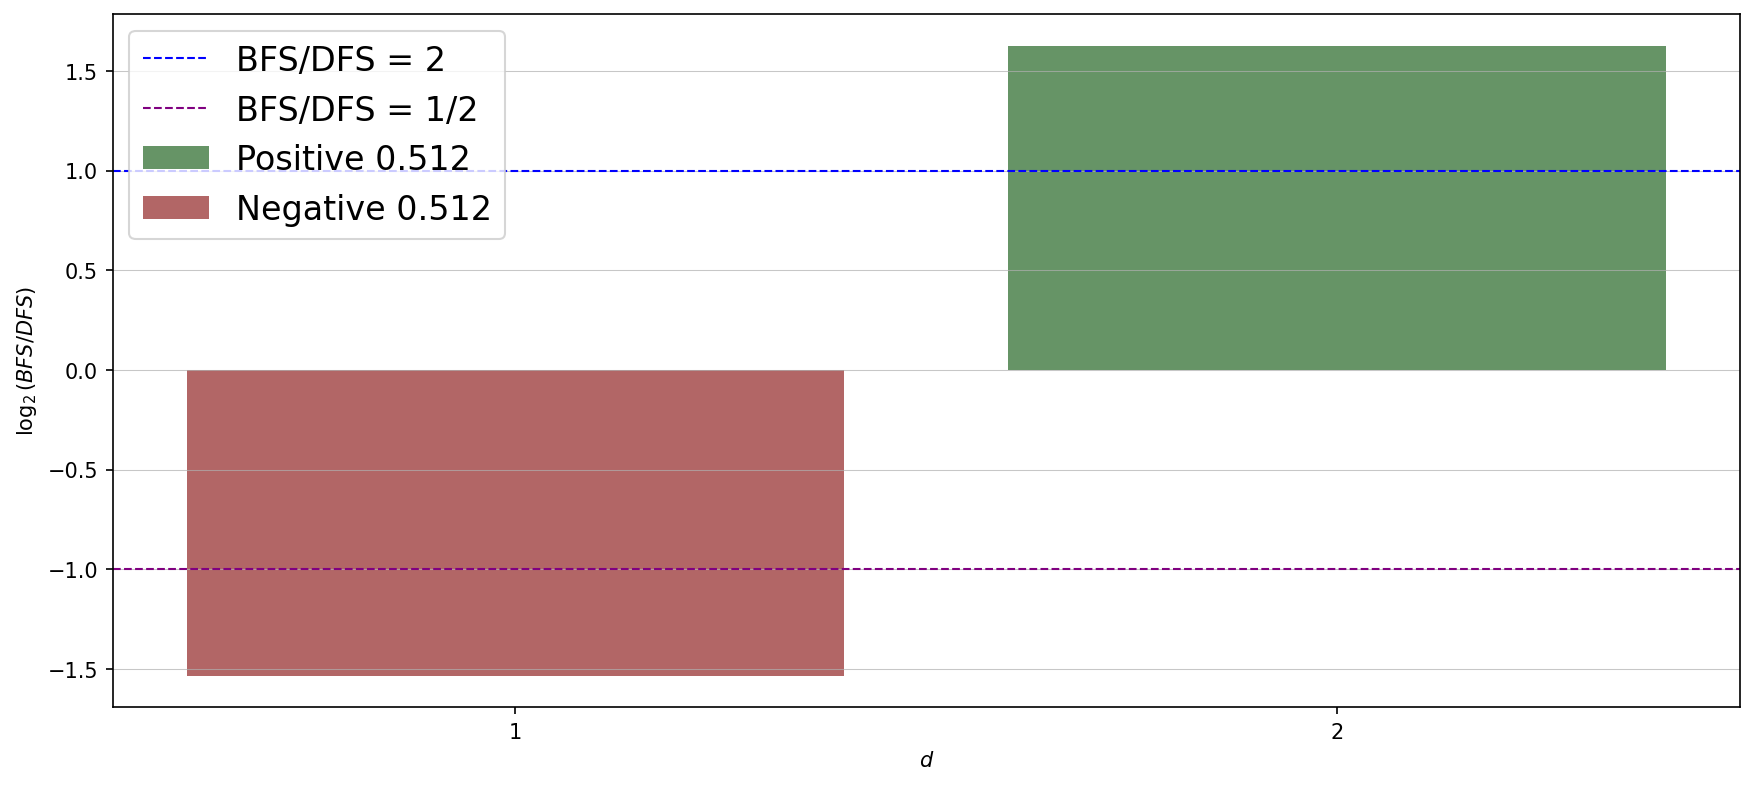

In [20]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

for density_column in log_ratios_by_density.columns[1:]:  # Пропускаем первый столбец "Distance"
    plt.figure(figsize=(14, 6), dpi=150)  # Увеличиваем размер картинки и разрешение

    positive_mask = log_ratios_by_density[density_column] > 0
    negative_mask = log_ratios_by_density[density_column] <= 0

    plt.bar(log_ratios_by_density['Distance'][positive_mask],
            log_ratios_by_density[density_column][positive_mask],
            label=f'Positive {density_column}', color=(0, 0.3, 0, 0.6), width=0.8)

    plt.bar(log_ratios_by_density['Distance'][negative_mask],
            log_ratios_by_density[density_column][negative_mask],
            label=f'Negative {density_column}', color=(0.5, 0, 0, 0.6), width=0.8)

    plt.axhline(y=1, color='blue', linestyle='--', label='BFS/DFS = 2', linewidth=1)
    plt.axhline(y=-1, color='purple', linestyle='--', label='BFS/DFS = 1/2', linewidth=1)

    #plt.title(f'$\\log_2(BFS/DFS)$ vs $r$ при $d$ = {density_column}')
    plt.xlabel('$d$')
    plt.ylabel(f'$\\log_2(BFS/DFS)$')

    plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))

    # Увеличиваем шрифт легенды
    plt.legend(fontsize=16)

    plt.grid(axis='y', linewidth=0.5, alpha=0.7)
    plt.show()

Есть [теорема](https://neerc.ifmo.ru/wiki/index.php?title=%D0%A1%D0%BB%D1%83%D1%87%D0%B0%D0%B9%D0%BD%D1%8B%D0%B5_%D0%B3%D1%80%D0%B0%D1%84%D1%8B), которая говорит, что при плотности, большей, чем $\sqrt{\frac{2\ln{p}}{p}}$, диаметр случайного графа не превышает 2. Это и можно заметить на графиках выше.

C:\Users\skiva\AppData\Local\Temp\ipykernel_3708\4177606353.py:18: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


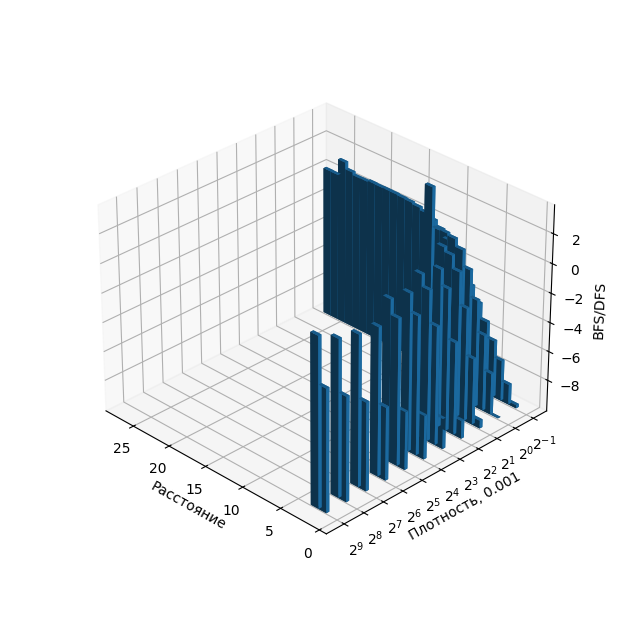

In [22]:
df = pd.read_csv('density/fulllog.txt', sep='\s+', header=None, names=['p', 'Density', 'Distance', 'BFS_Result', 'DFS_Result'])
df = df.groupby(['Density', 'Distance']).agg({'BFS_Result': ['mean', 'count'], 'DFS_Result': 'mean', 'p': 'first'}).reset_index()
df.columns = ['Density', 'Distance', 'BFS Avg', 'Count', 'DFS Avg', 'p']
df['BFS/DFS'] = np.log2(df['BFS Avg'] / df['DFS Avg'])

df['Density'] = np.log2(df['Density']/0.001)
y_ticks = np.linspace(-1, 9, endpoint=True, num=11)
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(projection='3d')
ax.azim = 135
ax.bar3d(df['Distance'], df['Density'], min(df['BFS/DFS']), 1, 0.15, df['BFS/DFS']-min(df['BFS/DFS']))
ax.set_xlabel('Расстояние')
ax.set_ylabel('Плотность, 0.001')
ax.set_zlabel('BFS/DFS')
ax.set_yticks(y_ticks, labels=[f"$2^{{{i}}}$" for i in range(-1, 10)])
ax.set_yticklabels([f"$2^{{{i}}}$" for i in range(-1, 10)])
ax.set_box_aspect(None, zoom=0.8)
fig.show()

C:\Users\skiva\AppData\Local\Temp\ipykernel_3708\2487259303.py:23: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


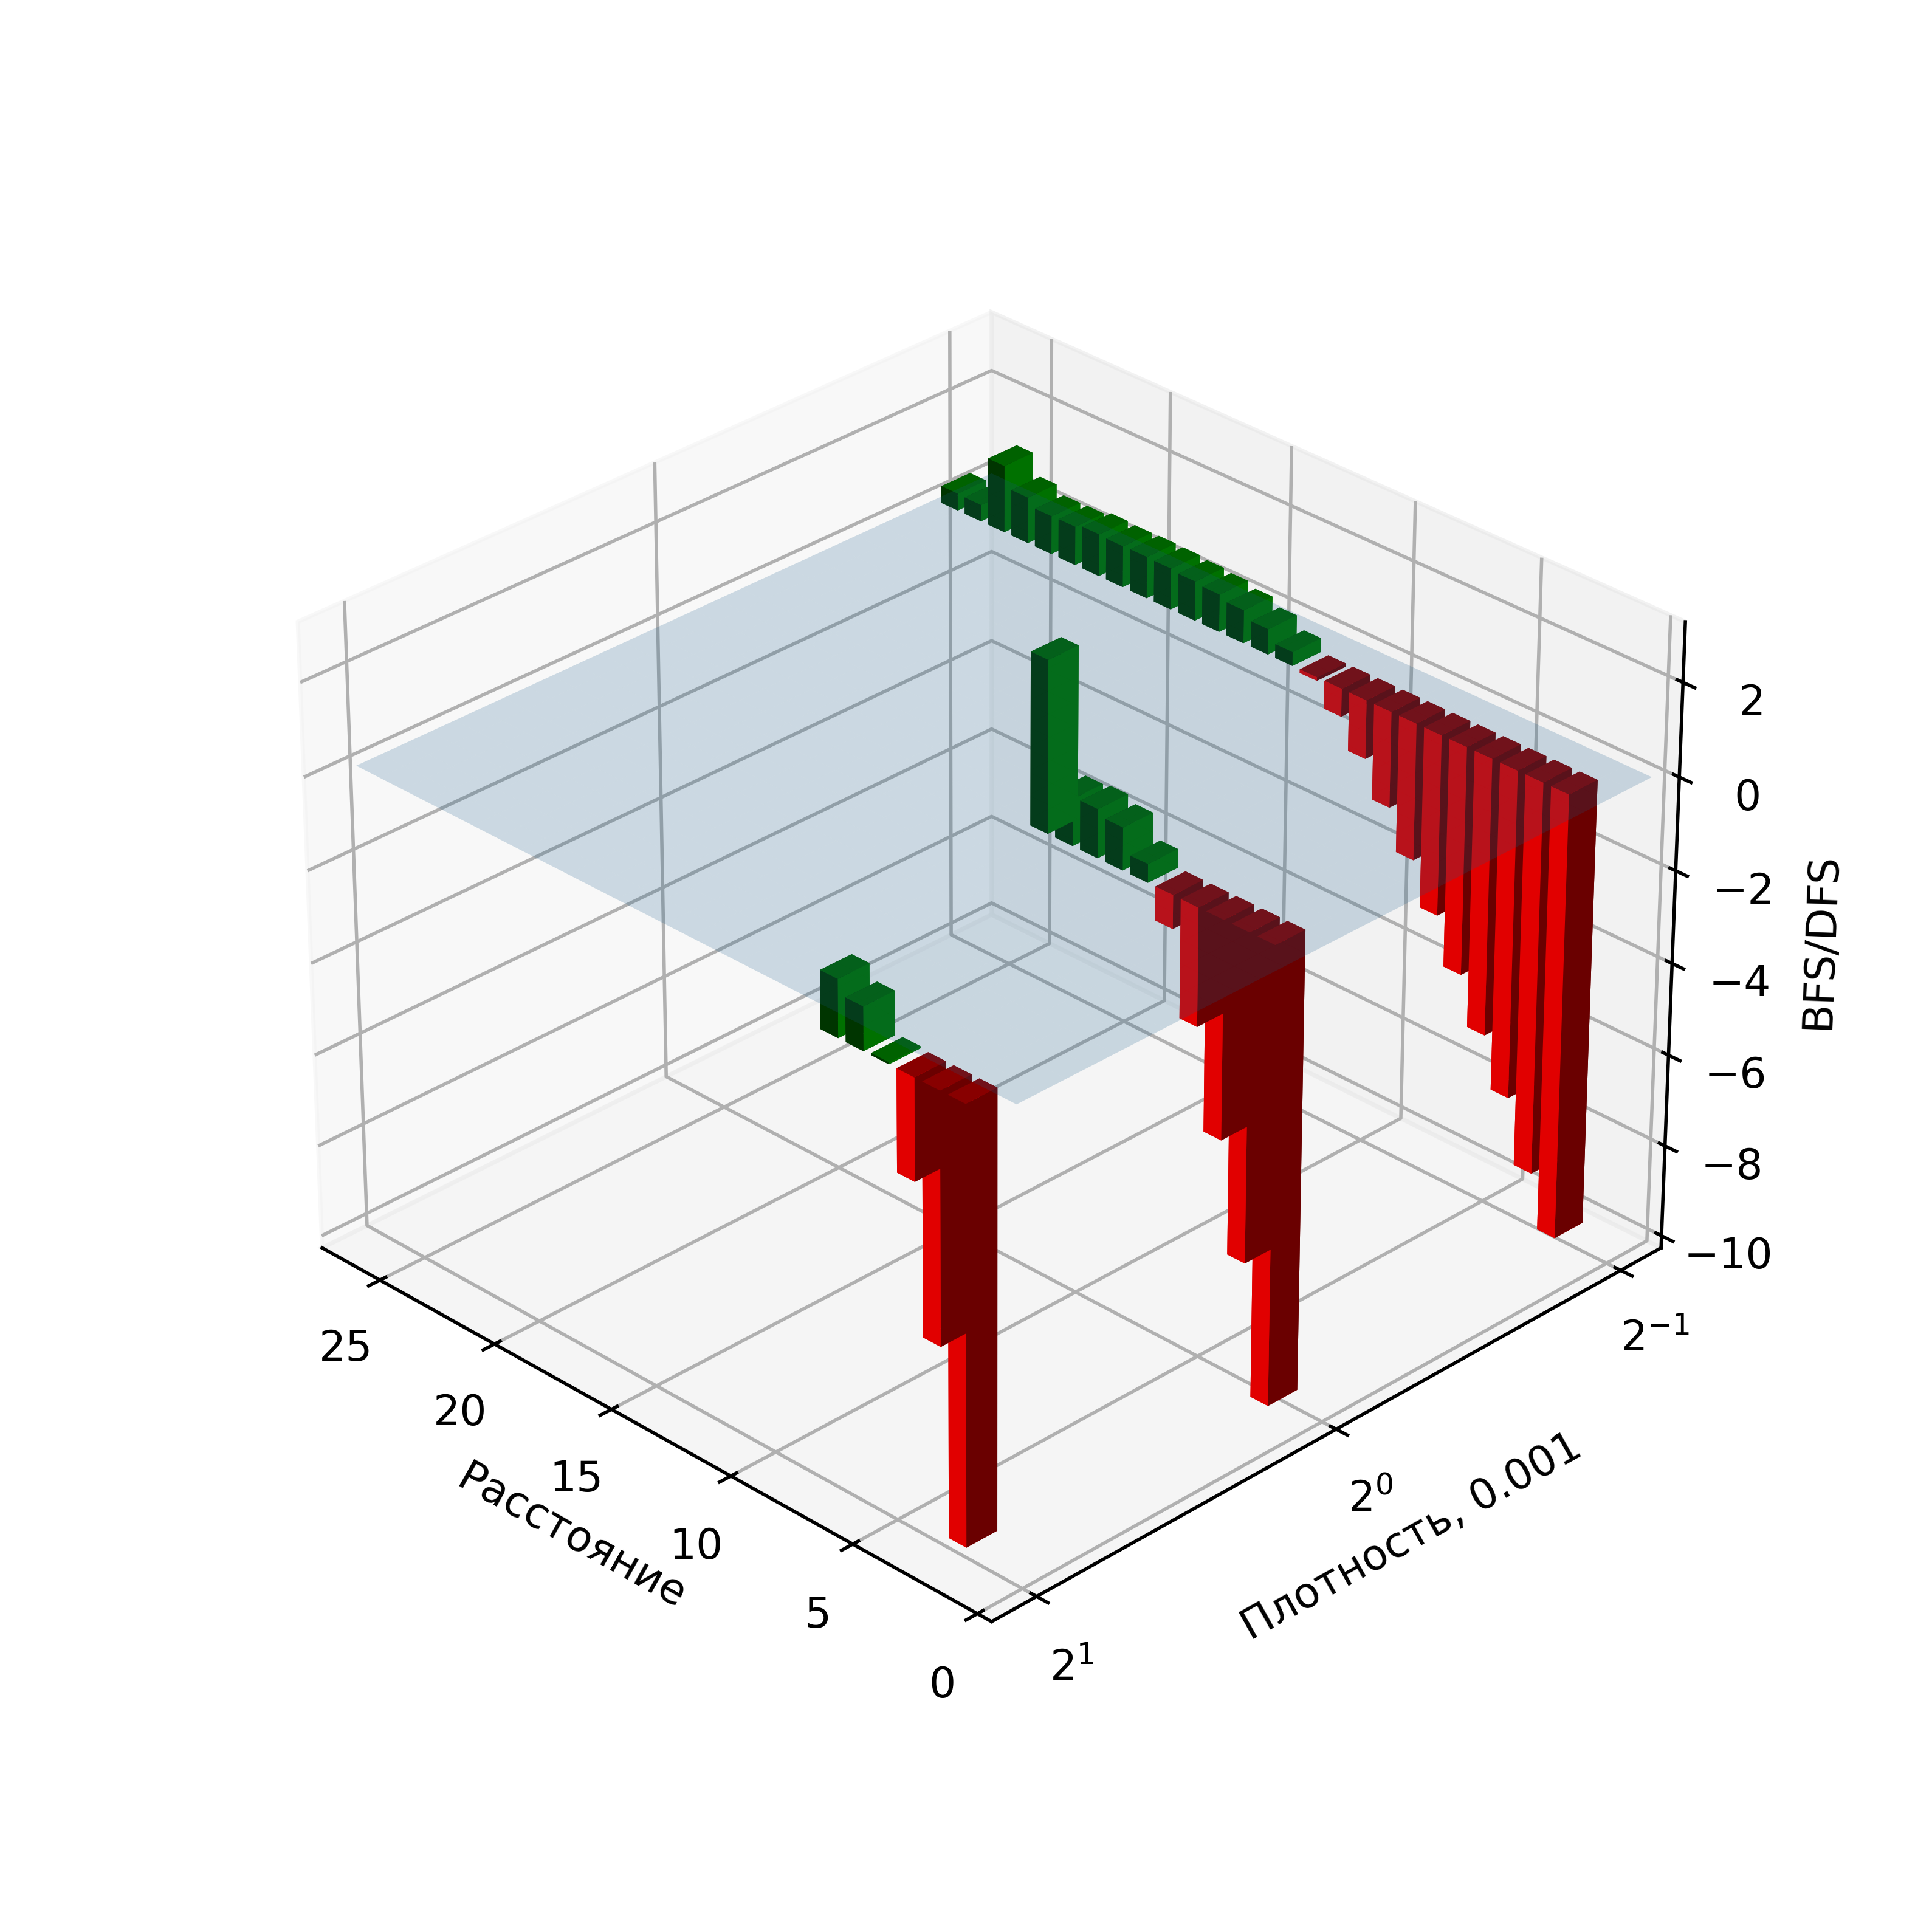

In [23]:
df_low_den = df[df['Density'] <= 1]
fig = plt.figure(figsize=(12, 8), dpi=500)
ax = fig.add_subplot(projection='3d')
ax.azim = 135
bdp = df_low_den[df_low_den['BFS/DFS'] > 0]
bdm = df_low_den[df_low_den['BFS/DFS'] <= 0]
ax.bar3d(bdm['Distance'], bdm['Density'], 0, 0.7, 0.1, bdm['BFS/DFS'], color='r')
ax.bar3d(bdp['Distance'], bdp['Density'], 0, 0.7, 0.1, bdp['BFS/DFS'], color='g')
ax.set_xlabel('Расстояние')
ax.set_ylabel('Плотность, 0.001')
ax.set_zlabel('BFS/DFS')
ax.set_xlim(0, 27)
ax.set_ylim(-1.1, 1.1)
ax.set_zlim(-10, 3)

xx, yy = np.meshgrid(range(28), range(28))
zz = xx*yy*0
ax.plot_surface(xx, yy/28*2.2 - 1.1, zz, alpha=0.2)
y_ticks = np.linspace(-1, 1, endpoint=True, num=3)
ax.set_yticks(y_ticks, labels=[f"$2^{{{i}}}$" for i in range(-1, 2)])
ax.set_yticklabels([f"$2^{{{i}}}$" for i in range(-1, 2)])
ax.set_box_aspect(None, zoom=0.8)
fig.show()

C:\Users\skiva\AppData\Local\Temp\ipykernel_3708\1936405134.py:23: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


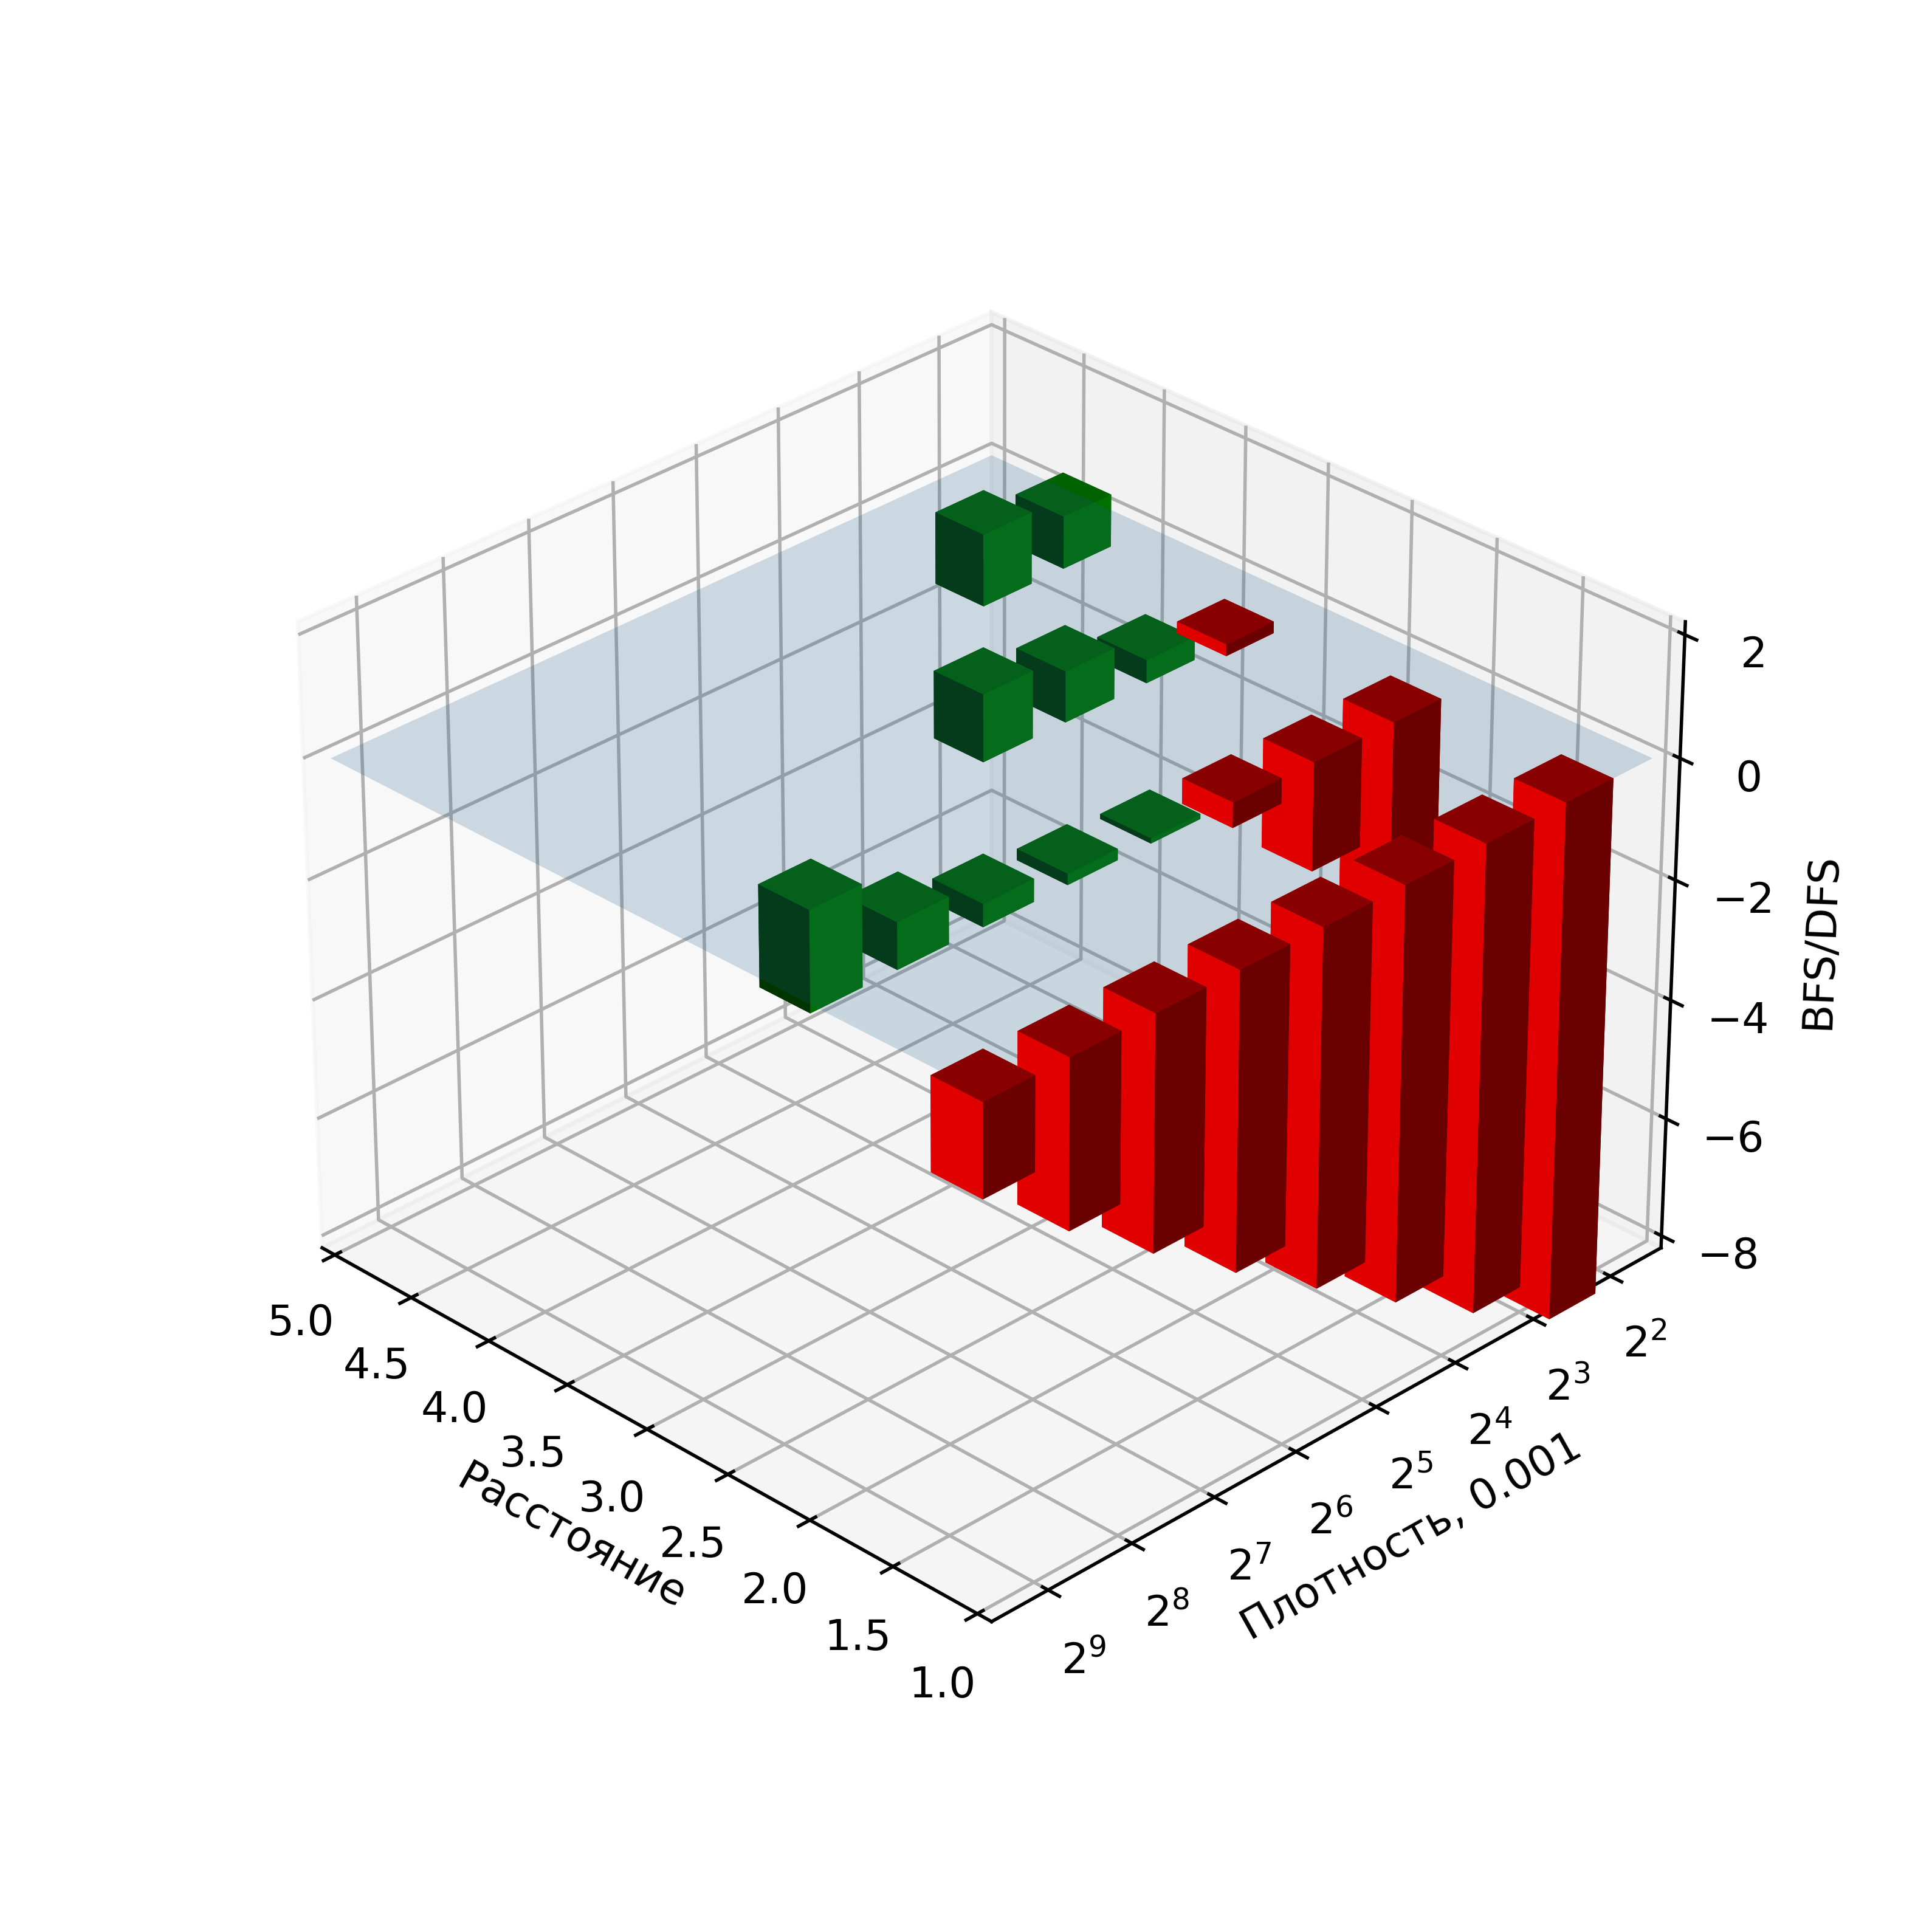

In [24]:
df_high_den = df[df['Density'] > 1]
fig = plt.figure(figsize=(12, 8), dpi=500)
ax = fig.add_subplot(projection='3d')
ax.view_init(azim=135)
bdp = df_high_den[df_high_den['BFS/DFS'] > 0]
bdm = df_high_den[df_high_den['BFS/DFS'] <= 0]
#ax.bar3d(df_high_den['Distance'], df_high_den['Density'], min(df_high_den['BFS/DFS']), 1, 1, df_high_den['BFS/DFS']-min(df_high_den['BFS/DFS']))
ax.bar3d(bdm['Distance'], bdm['Density'], 0, 0.3, 0.6, bdm['BFS/DFS'], color='r')
ax.bar3d(bdp['Distance'], bdp['Density'], 0, 0.3, 0.6, bdp['BFS/DFS'], color='g')
ax.set_xlabel('Расстояние')
ax.set_ylabel('Плотность, 0.001')
ax.set_zlabel('BFS/DFS')
ax.set_xlim(1, 5)
ax.set_ylim(1.5, 9.5)
ax.set_zlim(-8, 2)
xx, yy = np.meshgrid(range(1, 6), range(5))
zz = xx*yy*0
ax.plot_surface(xx, yy*2 + 1.5, zz, alpha=0.2)
y_ticks = np.linspace(2, 9, endpoint=True, num=8)
ax.set_yticks(y_ticks, labels=[f"$2^{{{i}}}$" for i in range(2, 10)])
ax.set_yticklabels([f"$2^{{{i}}}$" for i in range(2, 10)])
ax.set_box_aspect(None, zoom=0.8)
fig.show()

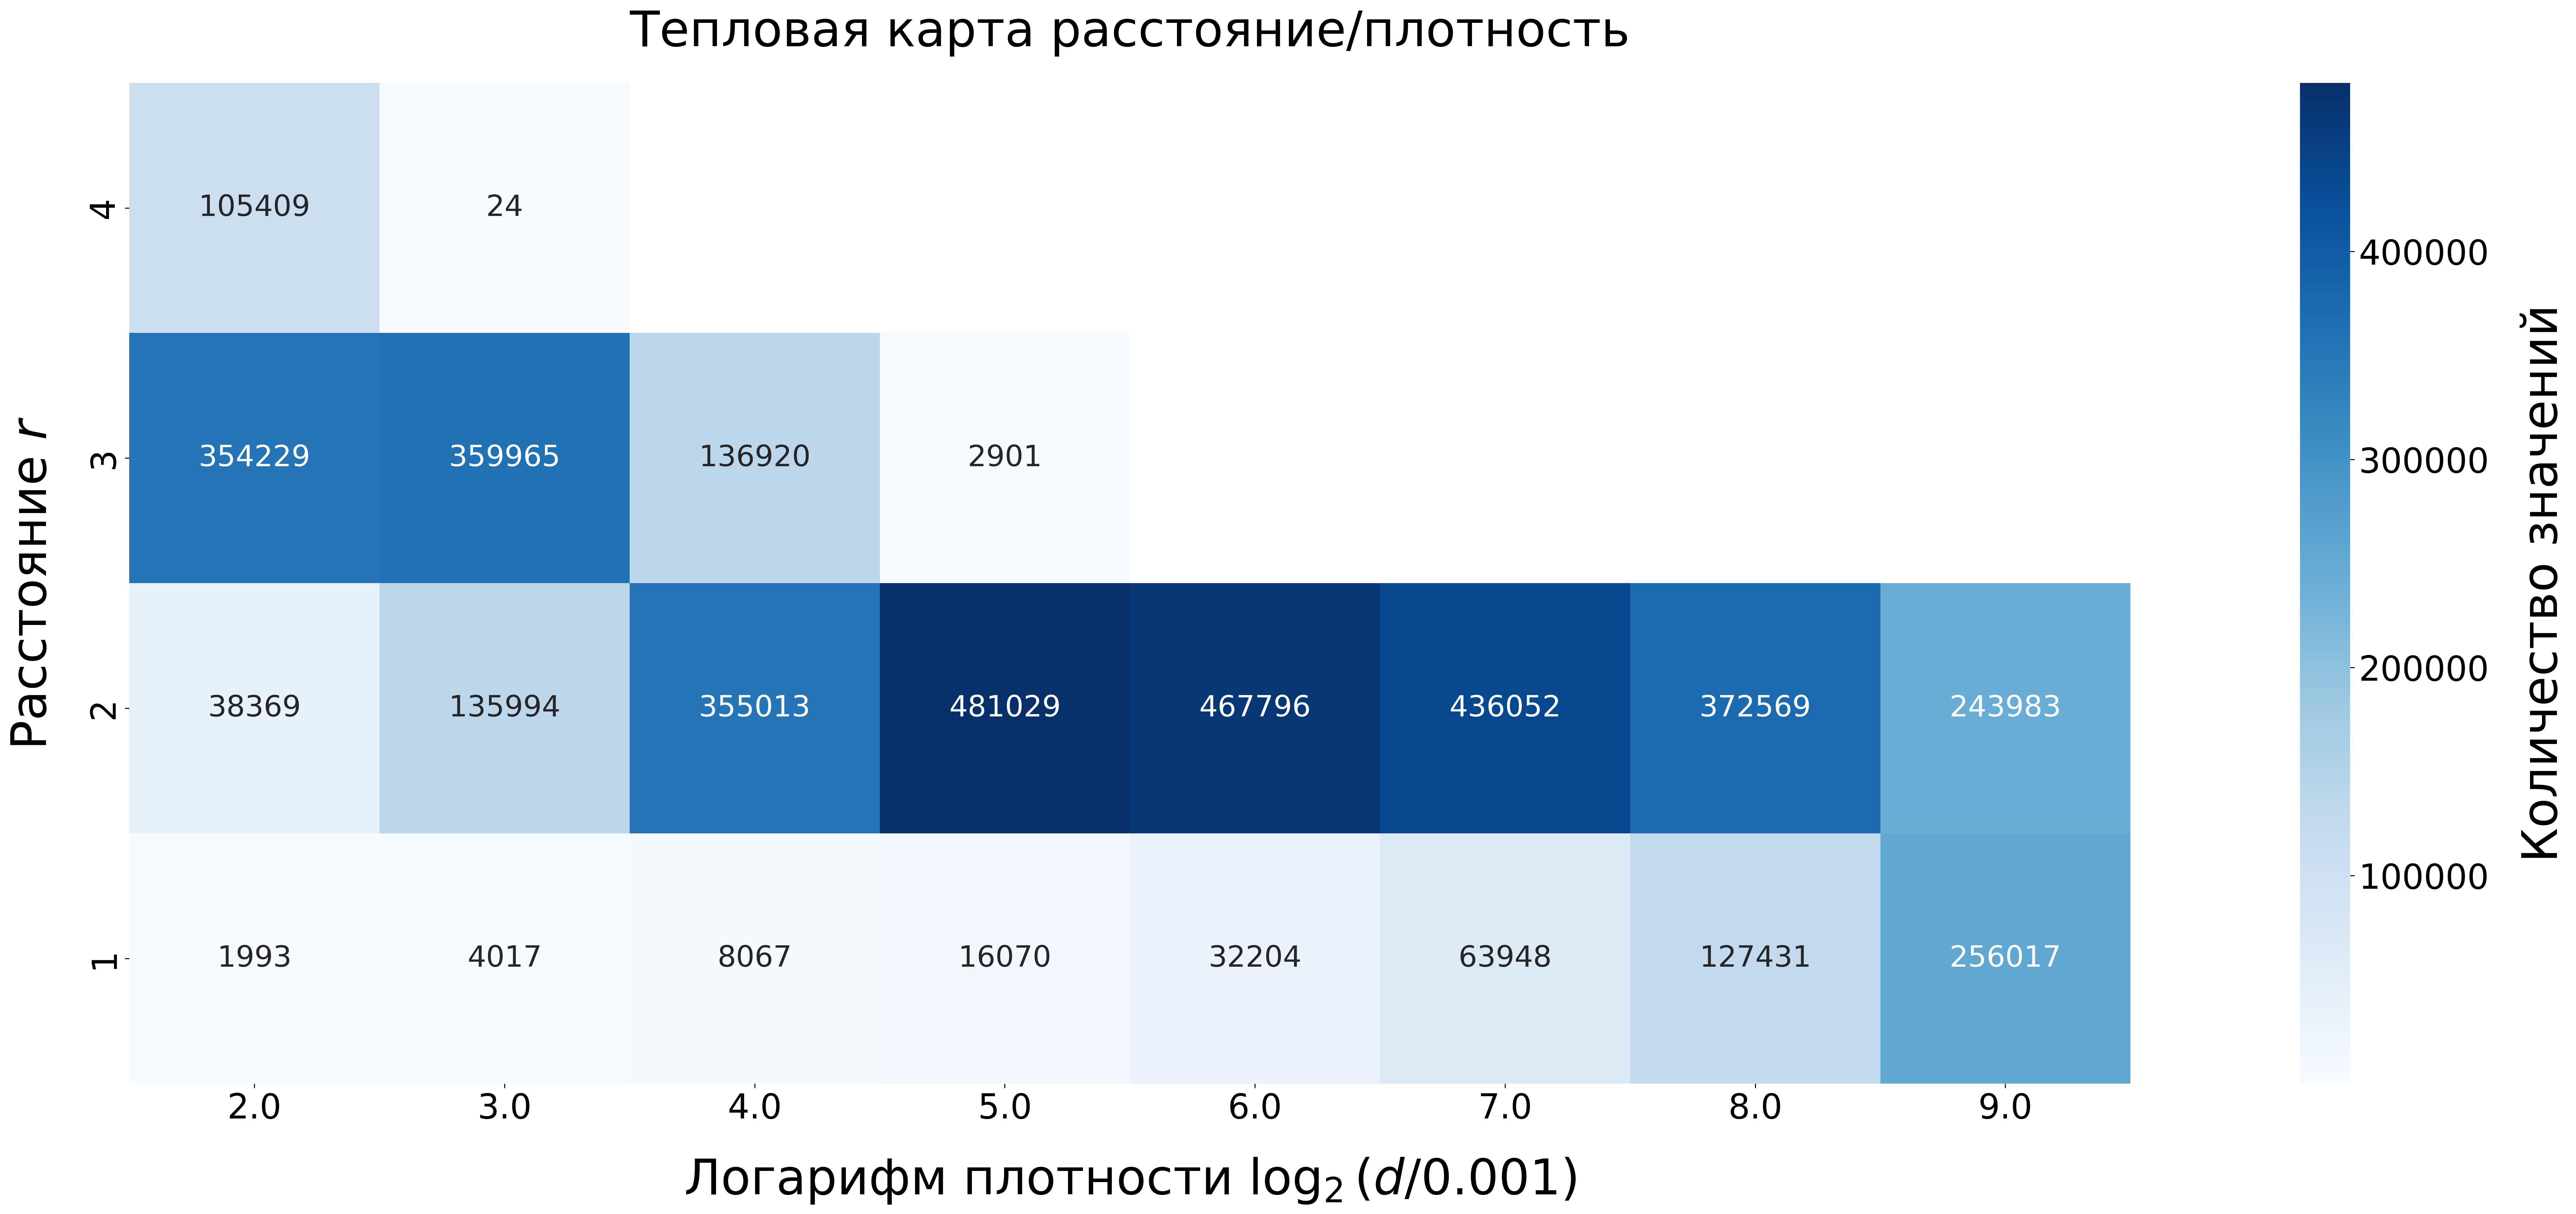

In [26]:
count_table = df_high_den.groupby(['Density', 'Distance'])['Count'].sum().unstack(fill_value=0)
count_table

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

mask = count_table == 0
fig, ax = plt.subplots(figsize=(40, 15), dpi=300)  # Установлен большой размер и высокий DPI

# Транспонируем как данные, так и маску
sns.heatmap(count_table.T, cmap='Blues', annot=True, fmt='d', ax=ax, cbar_kws={'label': 'Количество значений'},
            linewidths=0, linecolor='white', square=True, annot_kws={"size": 24}, mask=mask.T)

# Инвертируем оси
ax.invert_yaxis()  # Инвертируем ось Y, чтобы значения шли снизу вверх
# ax.invert_xaxis()  # Инвертируем ось X, чтобы значения шли слева направо

ax.set_xlabel('Логарифм плотности $\log_2{(d/0.001)}$', fontsize=40, labelpad=25)
ax.set_ylabel('Расстояние $r$', fontsize=40, labelpad=25)
ax.set_title('Тепловая карта расстояние/плотность', fontsize=40, pad=30)

ax.tick_params(axis='both', which='major', labelsize=28)

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=28)
cbar.set_label('Количество значений', fontsize=40, labelpad=25)

plt.tight_layout(pad=5)
plt.show()

# Модель Гильберта

In [110]:
# Чтение файла логов в датафрейм
df = pd.read_csv('logger/log.txt', sep='\s+', header=None, names=['p', 'Density', 'Distance', 'BFS_Result', 'DFS_Result'])

# Вычисление средних значений по плотности
averages_by_density = df.groupby('Density').agg({'BFS_Result': 'mean', 'DFS_Result': 'mean', 'Distance': 'mean', 'p': 'first'}).reset_index()
averages_by_density.rename(columns={'BFS_Result': 'BFS Avg', 'DFS_Result': 'DFS Avg', 'Distance': 'Distance Avg'}, inplace=True)

# Вычисление средних значений по (плотность, расстояние) с количеством пар
averages_by_density_distance = df.groupby(['Density', 'Distance']).agg({'BFS_Result': ['mean', 'count'], 'DFS_Result': 'mean', 'p': 'first'}).reset_index()
averages_by_density_distance.columns = ['Density', 'Distance', 'BFS Avg', 'Count', 'DFS Avg', 'p']
averages_by_density_distance['BFS/DFS'] = averages_by_density_distance['BFS Avg'] / averages_by_density_distance['DFS Avg']
averages_by_density_distance = averages_by_density_distance.dropna(subset=['BFS/DFS'])
averages_by_density = averages_by_density[['Density', 'p', 'BFS Avg', 'DFS Avg', 'Distance Avg']]
averages_by_density_distance = averages_by_density_distance[['Density', 'p', 'Distance', 'BFS Avg', 'DFS Avg', 'Count', 'BFS/DFS']]

print("Средние значения по плотности:")
print(averages_by_density)
final_df = averages_by_density_distance.copy()
final_df = final_df.sort_values(by=['p', 'Density'])
#final_df.set_index('Density', inplace=True)
final_df

Средние значения по плотности:
       Density     p  BFS Avg  DFS Avg  Distance Avg
0     0.497091  1000    885.0    421.0           2.0
1     0.497267  1000    230.0    772.0           1.0
2     0.497580  1000    756.0     88.0           2.0
3     0.497612  1000    847.0    167.0           2.0
4     0.497708  1000    598.0    430.0           2.0
...        ...   ...      ...      ...           ...
1681  0.502314  1000    916.0    376.0           2.0
1682  0.502320  1000    319.0    683.0           1.0
1683  0.502488  1000     72.0    930.0           1.0
1684  0.502517  1000     41.0    961.0           1.0
1685  0.502651  1000    757.0     35.0           2.0

[1686 rows x 5 columns]


,Density,p,Distance,BFS Avg,DFS Avg,Count,BFS/DFS
0,0.497091,1000,2,885.0,421.0,1,2.102138
1,0.497267,1000,1,230.0,772.0,1,0.297927
2,0.497580,1000,2,756.0,88.0,1,8.590909
3,0.497612,1000,2,847.0,167.0,1,5.071856
4,0.497708,1000,2,598.0,430.0,1,1.390698
...,...,...,...,...,...,...,...
2933,0.502314,1000,2,916.0,376.0,1,2.436170
2934,0.502320,1000,1,319.0,683.0,1,0.467057
2935,0.502488,1000,1,72.0,930.0,1,0.077419
2936,0.502517,1000,1,41.0,961.0,1,0.042664


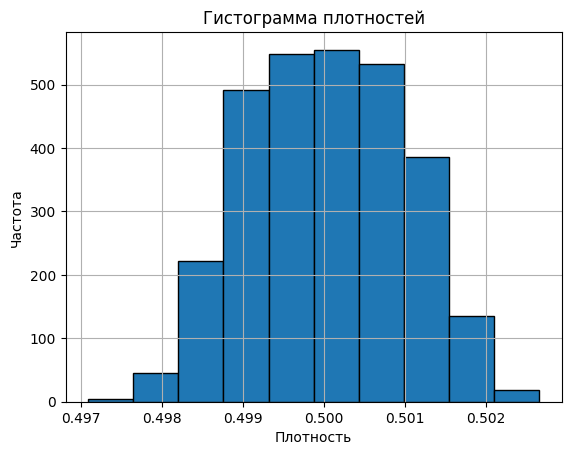

In [111]:
densities = averages_by_density_distance['Density'].to_numpy()
plt.hist(densities, bins=10, edgecolor='black')  # можно изменить bins по желанию
plt.title('Гистограмма плотностей')
plt.xlabel('Плотность')
plt.ylabel('Частота')
plt.grid(True)
plt.show()

In [109]:
mean = np.mean(densities)
std_sample = np.std(densities, ddof=1)

print(f"Математическое ожидание (среднее): {mean}")
print(f"Выборочное стандартное отклонение: {std_sample}")

Математическое ожидание (среднее): 0.5000207663551401
Выборочное стандартное отклонение: 0.0009191092098924048
